# IPI — data exploration starter

**Runs anywhere.** The root is discovered from the notebook's location, not hardcoded,
and every section checks whether its data is present before touching it. On a fresh
clone you get §1, §2 (small panel) and §4's log; §3 and the raw HTML need the full
data directory, which is not in git.

Storage is flat files — no database — in four tiers, each wanting a different tool:

| tier | where | size | in git? | tool |
|---|---|---|---|---|
| derived indices | `data/pilot/*.csv`, `docs/*.json` | KB | yes | `pd.read_csv` |
| price panels | `data/pilot/*-prices.csv` | 0.6–85 MB | small ones only | `pd.read_csv` |
| pipeline intermediates | `data/cdx-index/*.tsv` | 1.3–5.8 GB | **no** | **duckdb** |
| raw archived pages | `data/pilot/html*/` | 86 GB | **no** | `gzip.open`, one at a time |

A full clone is ~44 MB. The other 124 GB lives only on the collection machine.

In [34]:
import os, sys, gzip, json, re
from pathlib import Path
import numpy as np, pandas as pd

def find_root(start=None):
    """Project root = nearest ancestor holding CLAUDE.md and data/. No hardcoded paths."""
    start = Path(start or Path.cwd()).resolve()
    for p in (start, *start.parents):
        if (p / "CLAUDE.md").exists() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"project root not found above {start}")

ROOT = find_root()
os.chdir(ROOT)                      # every data path below is repo-relative
sys.path.insert(0, str(ROOT / "code"))   # so `import gigfilter` works, as in the scripts

try:
    import duckdb
except ImportError:
    duckdb = None

print("root    ", ROOT)
print("pandas  ", pd.__version__)
print("duckdb  ", duckdb.__version__ if duckdb else "NOT INSTALLED — §3 will skip")

root     /Users/arushipatra/Desktop/IntelligencePriceIndex
pandas   2.3.3
duckdb   NOT INSTALLED — §3 will skip


### Preflight — what data is actually on this machine

In [35]:
def first_present(*paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

# price panels, largest first — the big two are gitignored, the small ones are tracked
# .gz first: the 88 MB CSVs are gitignored, the 8 MB gzips are committed and
# pd.read_csv reads them transparently. On a fresh clone this resolves to the
# same balanced panel the collection machine uses -- not a thin fallback.
PRICES = first_present("data/pilot/balanced-prices.csv", "data/pilot/balanced-prices.csv.gz",
                       "data/pilot/expanded-prices.csv", "data/pilot/expanded-prices.csv.gz",
                       "data/pilot/pilot-prices.csv")
GMI    = first_present("data/cdx-index/gig-month-index.tsv")
HTML   = first_present("data/pilot/html-balanced", "data/pilot/html-recent", "data/pilot/html")
NICHE  = first_present("data/pilot/niche-assignment.csv")

def mb(p):
    if p is None: return "-"
    if p.is_dir(): return "dir"
    return f"{p.stat().st_size/1e6:,.1f} MB"

for label, p in [("price panel", PRICES), ("cdx index", GMI), ("html store", HTML), ("niches", NICHE)]:
    print(f"{label:12s} {'OK ' if p else 'ABSENT':4s} {str(p or ''):45s} {mb(p)}")

price panel  OK   data/pilot/balanced-prices.csv.gz             7.9 MB
cdx index    ABSENT                                               -
html store   ABSENT                                               -
niches       OK   data/pilot/niche-assignment.csv               3.9 MB


## 1. Derived indices — tiny, git-tracked, always available

In [36]:
ipi   = pd.read_csv("data/pilot/recent-ipi.csv")                     # quarter, ipi
panel = pd.read_csv("data/pilot/panel-ipi.csv")                      # long historical panel
cats  = pd.read_csv("data/pilot/recent-category-indices-geks.csv")   # quarter x 7 categories

display(ipi.tail())
display(cats.tail())

,quarter,ipi
2,2025Q1,101.00
3,2025Q2,105.66
4,2025Q3,109.05
5,2025Q4,110.51
6,2026Q1,110.12


,quarter,audio,coding,design,marketing,translation,video,writing
2,2025Q1,103.31,93.19,99.45,100.89,131.92,93.81,110.07
3,2025Q2,111.53,97.10,105.91,99.81,134.79,108.95,107.68
4,2025Q3,111.96,106.14,106.44,107.95,120.94,110.16,108.81
5,2025Q4,114.83,118.13,108.58,107.84,129.89,109.61,111.11
6,2026Q1,104.85,121.44,106.43,109.94,131.51,96.87,108.50


In [37]:
# the numbers frozen into the paper and the website
paper = json.load(open("data/pilot/paper-numbers.json"))
site  = json.load(open("docs/data.json"))
print(sorted(paper)[:20])
print({k: site[k] for k in ("generated", "cadence", "base_period", "panel_gigs")})

['adequacy_rule_pct', 'base_period', 'categories', 'composite', 'cpi_change_pct', 'data_generated', 'n_quarters', 'reputation_band', 'source', 'window']
{'generated': '2026-07-31', 'cadence': 'quarterly', 'base_period': '2020Q1', 'panel_gigs': {'audio': 55, 'coding': 462, 'design': 1466, 'marketing': 294, 'translation': 28, 'video': 235, 'writing': 368}}


## 2. The price panel

One row per (gig, archived snapshot) with the three Fiverr package tiers.
`file_path` points back to the exact archived HTML the price came from — that is
the lineage hook; use it whenever a number looks wrong.

In [38]:
px = pd.read_csv(PRICES)
print(f"{PRICES}  ->  {px.shape[0]:,} rows x {px.shape[1]} cols, "
      f"{px.memory_usage(deep=True).sum()/1e6:.0f} MB resident")
px.head(3)

data/pilot/balanced-prices.csv.gz  ->  292,447 rows x 13 cols, 166 MB resident


,seller,slug,date,year,month,price_basic,price_standard,price_premium,title,rating,review_count,extraction_method,file_path
0,a1000voices,record-a-voice-over-or-message-as-sam-elliott,20230313,2023,3,25.0,NaN,NaN,A1000voices: I will record a voice over or mes...,5.0,54.0,packageList,data/pilot/html-balanced/a1000voices/20230313_...
1,a1000voices,record-a-voice-over-or-message-as-sam-elliott,20230510,2023,5,25.0,NaN,NaN,A1000voices: I will record a voice over or mes...,5.0,59.0,packageList,data/pilot/html-balanced/a1000voices/20230510_...
2,a1000voices,record-a-voice-over-or-message-as-sam-elliott,20230717,2023,7,35.0,NaN,NaN,A1000voices: I will record a voice over or mes...,5.0,67.0,packageList,data/pilot/html-balanced/a1000voices/20230717_...


In [39]:
(px.groupby("year")
   .agg(n=("price_basic", "size"),
        median_basic=("price_basic", "median"),
        sellers=("seller", "nunique"))
   .assign(median_basic=lambda d: d.median_basic.round(2)))

,n,median_basic,sellers
year,,,
2018,13408,10.0,6446
2019,35544,15.0,11447
2020,48802,15.0,15647
2021,48810,20.0,16114
2022,50290,25.0,16265
2023,45310,25.0,15011
2024,43989,30.0,14773
2025,5644,25.0,3306
2026,650,25.0,632


## 3. Big pipeline intermediates — duckdb, not pandas

`gig-month-index.tsv` is 1.3 GB and headerless; the classified / deduped page
tables are ~5.7 GB each. duckdb scans them out-of-core in seconds where
`pd.read_csv` would exhaust memory. **Gitignored — this section needs the
collection machine.**

Gotcha: the parameterised form `read_csv(..., columns=$cols)` with
`params={"cols": {...}}` is *silently ignored*; duckdb falls back to dialect
sniffing and then fails on a headerless TSV. Render the struct inline.

In [40]:
if GMI is None or duckdb is None:
    print("SKIP — needs data/cdx-index/gig-month-index.tsv (1.3 GB, not in git) and duckdb")
else:
    GMI_SQL = (f"read_csv('{GMI}', delim='\\t', header=false, "
               "columns={'gig_id':'VARCHAR','month':'VARCHAR',"
               "'timestamp':'VARCHAR','category':'VARCHAR'})")

    display(duckdb.sql(f"""
        SELECT category, count(*) AS snapshots, count(DISTINCT gig_id) AS gigs
        FROM {GMI_SQL}
        GROUP BY 1 ORDER BY snapshots DESC
    """).df())

SKIP — needs data/cdx-index/gig-month-index.tsv (1.3 GB, not in git) and duckdb


In [41]:
if GMI is None or duckdb is None:
    print("SKIP — see above")
else:
    cov = duckdb.sql(f"""
        SELECT month, count(DISTINCT gig_id) AS gigs
        FROM {GMI_SQL}
        GROUP BY 1 ORDER BY 1
    """).df()
    print(f"{len(cov)} months, {cov.month.min()}-{cov.month.max()}")
    ax = cov.set_index("month").plot(figsize=(12, 3), legend=False,
                                     title="distinct gigs archived per month")
    ax.set_xlabel("")

SKIP — see above


## 4. Raw archived pages

`data/pilot/html-{recent,balanced}/<seller>/<YYYYMMDD>_<slug>.html.gz` — 86 GB.
Never glob the tree. Enter through the price panel's `file_path`, or through the
download logs.

In [42]:
row  = px.iloc[0]
cand = [Path(row.file_path.replace(".html", ".html.gz")), Path(row.file_path)]
path = next((p for p in cand if p.exists()), None)

if path is None:
    print(f"SKIP — HTML store not on this machine (wanted {cand[0]})")
else:
    html = (gzip.open(path, "rt", errors="replace").read() if path.suffix == ".gz"
            else path.read_text(errors="replace"))
    print(path, f"{len(html):,} chars")
    print(re.search(r"<title>(.*?)</title>", html, re.S).group(1)[:120])

SKIP — HTML store not on this machine (wanted data/pilot/html-balanced/a1000voices/20230313_record-a-voice-over-or-message-as-sam-elliott.html.gz.gz)


In [43]:
# the download logs are the cheap index into the HTML store — and they ARE in git
log = pd.read_csv("data/pilot/recent-download-log.tsv", sep="\t")
print(log.shape, log.status.value_counts().to_dict())
log.head(3)

(27521, 5) {'200': 15150, 'fail': 12336, '404': 32, '403': 3}


,timestamp,url,status,file_path,size
0,20241005043323,https://www.fiverr.com/a_samadshah/create-amaz...,200,data/pilot/html-recent/a_samadshah/20241005_cr...,1496722
1,20251228044607,https://www.fiverr.com/a_kumar07/design-credit...,200,data/pilot/html-recent/a_kumar07/20251228_desi...,1801616
2,20241002220215,https://www.fiverr.com/aadil_chan/do-linkedin-...,200,data/pilot/html-recent/aadil_chan/20241002_do-...,1487431


## 5. Niche assignment — the 2026-08 event-study work

In [44]:
if NICHE is None:
    print("SKIP — niche-assignment.csv not committed yet")
else:
    arr = pd.read_csv("data/pilot/niche-arrival.csv")
    asg = pd.read_csv(NICHE)
    print(asg.shape, "usable:", int(asg.usable.sum()))
    display(arr.dropna(subset=["arrival_quarter"])
               .sort_values("n_listings", ascending=False).head(10))

(39933, 4) usable: 38822


,niche,niche_label,n_listings,arrival_quarter,peak_ai_share
50,61,teach / lessons / online,267,2023Q3,0.1538
183,212,custom / create custom / create,227,2024Q3,0.0874
114,131,python / help / programming,215,2024Q3,0.0662
21,27,video / spokesperson / music video,187,2023Q3,0.0652
198,229,spokesperson / video / spokesperson video,160,2023Q3,0.1538
159,182,produce / music / compose,159,2024Q3,0.0909
136,154,music / video / music video,150,2023Q1,0.3396
42,53,videos / youtube videos / transcribe,146,2023Q3,0.0690
125,142,excel / data / entry,140,2024Q3,0.0571
70,85,art / create / draw,137,2023Q1,0.2500


## 6. Prices over time

From here on the notebook works on the **balanced panel** (`balanced-prices.csv`,
292k rows / 39.6k gigs after filters), built through `code/64-event-study-twfe.py`
so the filters are the ones steps 19/21 apply — `is_gig` on the handle, a known
category, `0 < price <= $10,000`, then the gig-quarter median.

Two warnings that govern every chart below.

**The series is truncated at 2024Q4 on purpose.** 2025-26 exists in the file but
is 5.6k and 650 rows against ~45k/year before it — the 403/PerimeterX cliff, not
a market that stopped trading. `plans/todo.md` carries an open blocker requiring
those points be suppressed or hard-banded before they reach any exhibit. Set
`END_Q` later if you want to look at them, but do not plot them as measurements.

**A raw median per quarter is not a price index.** It moves when the *mix* of
gigs changes, and this market's entrants price above its incumbents (step 57 §4),
so composition alone pushes the median up. §7 and §8 are the two ways of removing
that; the gap between this chart and those is the composition effect.

In [45]:
import importlib.util
import matplotlib.pyplot as plt

def _load(name, rel):
    spec = importlib.util.spec_from_file_location(name, rel)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod

esm  = _load("es",   "code/64-event-study-twfe.py")   # panel builder + event study
geks = _load("geks", "code/21-geks-index.py")         # GEKS-Jevons, imported not rewritten
tpd  = geks.tpd

CATEGORY_CSV = "data/pilot/balanced-gig-category.csv.gz"   # committed, 0.9 MB
START_Q, END_Q = "2020Q1", "2024Q4"
LAUNCH, BASE   = esm.CHATGPT_LAUNCH, esm.DEFAULT_BASE      # 2022Q4 / 2022Q3

gq = esm.build_panel(PRICES, CATEGORY_CSV)
print(f"{PRICES}")
print(f"  {gq.attrs['rows_in']:,} rows in -> {gq.attrs['rows_kept']:,} kept "
      f"-> {len(gq):,} gig-quarter cells, {gq.gig_id.nunique():,} gigs")
print(f"  quarters {gq.quarter.min()}..{gq.quarter.max()}, "
      f"median {gq.groupby('gig_id').size().median():.0f} quarters per gig")

# The balanced sample holds at most one capture per gig-quarter, so the median
# collapse is a near no-op here. It matters on the other panels; keep it.
gq.head(3)

data/pilot/balanced-prices.csv.gz
  292,447 rows in -> 287,618 kept -> 287,618 gig-quarter cells, 39,593 gigs
  quarters 2018Q3..2026Q1, median 6 quarters per gig


,gig_id,category,quarter,price_basic,qi
0,a1000voices/record-a-voice-over-or-message-as-...,audio,2023Q1,25.0,20231
1,a1000voices/record-a-voice-over-or-message-as-...,audio,2023Q2,25.0,20232
2,a1000voices/record-a-voice-over-or-message-as-...,audio,2023Q3,35.0,20233


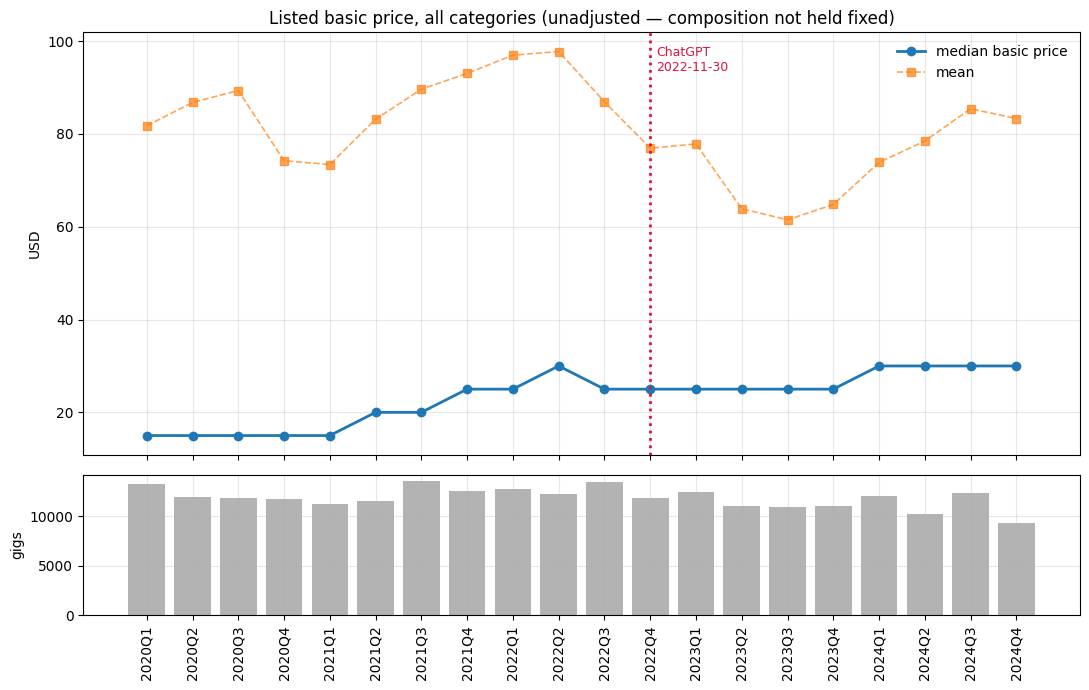

,median,mean,gigs
quarter,,,
2020Q1,15.0,81.78,13271
2020Q2,15.0,86.79,11932
2020Q3,15.0,89.37,11870
2020Q4,15.0,74.24,11723
2021Q1,15.0,73.41,11189
2021Q2,20.0,83.20,11581
2021Q3,20.0,89.65,13522
2021Q4,25.0,93.07,12508
2022Q1,25.0,96.99,12755


In [46]:
w = gq[(gq.qi >= esm.q_to_int(START_Q)) & (gq.qi <= esm.q_to_int(END_Q))]

overall = (w.groupby("quarter")
             .agg(median=("price_basic","median"), mean=("price_basic","mean"),
                  gigs=("gig_id","nunique"))
             .sort_index(key=lambda s: s.map(esm.q_to_int)))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                             gridspec_kw={"height_ratios":[3,1]})
a1.plot(overall.index, overall["median"], "o-", lw=2, label="median basic price")
a1.plot(overall.index, overall["mean"], "s--", lw=1.2, alpha=.7, label="mean")
a1.axvline(LAUNCH, color="crimson", ls=":", lw=2)
a1.annotate("ChatGPT\n2022-11-30", xy=(LAUNCH, a1.get_ylim()[1]),
            xytext=(4,-28), textcoords="offset points", color="crimson", fontsize=9)
a1.set_ylabel("USD"); a1.legend(frameon=False); a1.grid(alpha=.3)
a1.set_title("Listed basic price, all categories (unadjusted — composition not held fixed)")

a2.bar(overall.index, overall["gigs"], color="0.7")
a2.set_ylabel("gigs"); a2.grid(alpha=.3)
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

display(overall.assign(median=lambda d: d["median"].round(2),
                       mean=lambda d: d["mean"].round(2)))

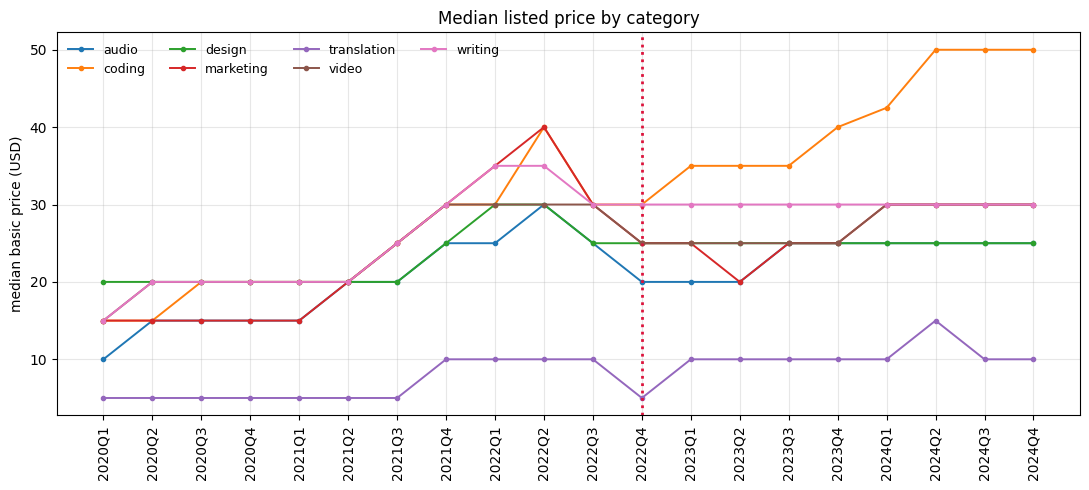

In [47]:
# by category — same caveat, composition is not held fixed
fig, ax = plt.subplots(figsize=(11, 5))
for c in tpd.CATS:
    s = (w[w.category == c].groupby("quarter").price_basic.median()
           .sort_index(key=lambda s: s.map(esm.q_to_int)))
    ax.plot(s.index, s.values, "o-", ms=3, lw=1.4, label=c)
ax.axvline(LAUNCH, color="crimson", ls=":", lw=2)
ax.set_ylabel("median basic price (USD)"); ax.grid(alpha=.3)
ax.legend(ncol=4, frameon=False, fontsize=9)
ax.set_title("Median listed price by category")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

## 7. GEKS-Jevons index — 35 fine-grained categories, nominal and real

`geks_index()` is **imported from `code/21-geks-index.py`**, not reimplemented, so
what the notebook plots is the estimator the papers use. For every pair of quarters
it forms the direct bilateral Jevons comparison over gigs present in *both*,

$$\ln P(s,t) \;=\; \frac{1}{|G_{s,t}|}\sum_{i \in G_{s,t}} \bigl(\ln p_{i,t} - \ln p_{i,s}\bigr)$$

then makes those transitive by averaging every route through a link quarter $l$:

$$\ln P_{\text{GEKS}}(s,t) \;=\; \frac{1}{L}\sum_{l}\bigl[\ln P(s,l) + \ln P(l,t)\bigr]$$

The gig's price *level* cancels inside each bilateral difference, so there is no
fixed effect to estimate and no chain to drift along — this is a matched-model
index, and it answers §6's composition problem by construction. A pair needs
`MIN_MATCH = 3` matched gigs to count; `pair_density` reports the share of pairs
that clear it, and is the main way GEKS degrades on thin categories.

Bootstrap SEs resample **gigs** (200 draws in the pipeline; 100 here — this is the
slow cell, ~2 min). Base quarter is the first in the window, pinned to 100.

Two things differ from the seven-line chart the site publishes.

**Finer categories.** `code/66-narrow-real-geks.py` subdivides each broad domain
with the taxonomy `code/16-subclassify-narrow.py` already owns — keyword matches on
the gig slug *within* its parent — giving **35 buckets** (Logo & Brand, Backend &
API, Voiceover, Subtitles & Transcribe, …). Step 16 warned that most subcategories
are too thin to chain on the recent *monthly* manifest; the balanced panel is
quarterly and matched-model, a much easier gate, and every bucket below clears all
20 quarters at `pair_density` 1.00. A bucket holding fewer than 100 gigs is folded
back into its parent's remainder rather than indexed on a handful of matched pairs.
The `· other` remainders are kept as first-class lines — in video and translation
they are the family's largest bucket, so dropping them would hide most of the gigs
— but they are labelled as remainders, not as niches.

**Nominal *and* real.** The bilaterals are formed over raw listed USD, so the first
chart still carries general US inflation inside it: CPI-U (SA) rose **22.3%** across
2020Q1–2024Q4, more than several categories move in total. The second chart divides
it out,

$$\text{Real}_{c,t} \;=\; \text{Nominal}_{c,t}\times \frac{\text{CPI}_{\text{base}}}{\text{CPI}_{t}}$$

the same definition and the same deflator file step 23 publishes for the site
panels. The deflator enters as a per-quarter constant carrying no sampling error,
so on the log scale it shifts the index by a zero-variance constant: **the nominal
bootstrap SEs apply unchanged to the real series**, which is why no separate real
bands are computed. Both charts share one y-axis, so the vertical gap between them
at quarter $t$ *is* the CPI-U rise from 2020Q1 to $t$, and anything still above 100
on the second chart is a real price increase.

In [48]:
import numpy as np

nrg = _load("nrg", "code/66-narrow-real-geks.py")   # narrow split + CPI-U deflator

N_BOOT = 100          # 0 to skip the bootstrap and run in seconds

wn     = nrg.add_narrow(w)               # step 16's slug keywords, inside each parent
cpi, _ = nrg.load_deflator()             # quarterly CPI-U (SA), written by step 23
LBL    = nrg.narrow_labels()             # category id -> (label, parent, colour)

# the same estimator at both levels: 35 narrow buckets, and the 7 domains for scale
nom_n, real_n, se_n, diag_n = nrg.geks_table(nrg.nested_by(wn, "narrow"),
                                             cpi, n_boot=N_BOOT, window_start=START_Q)
nom_b, real_b, se_b, diag_b = nrg.geks_table(nrg.nested_by(wn, "category"),
                                             cpi, n_boot=0, window_start=START_Q)
                                             # broad lines carry no band -> no bootstrap

cpi_line = pd.Series(nrg.cpi_rebased(cpi, nom_n.index, START_Q)).reindex(nom_n.index)
NARROW   = nrg.order_narrow(nom_n.columns)          # family-major, remainders last
geks_df  = nom_b                                    # §9 (AP) reads the broad table under its old name

print(f"{len(NARROW)} narrow categories x {len(nom_n)} quarters, "
      f"{wn.gig_id.nunique():,} gigs, {N_BOOT} bootstrap draws")
print(f"CPI-U (SA) {START_Q}->{END_Q}: {cpi_line.iloc[-1] - 100:+.1f}%  "
      f"— the wedge between the two charts below")
if wn.attrs["folded"]:
    print("folded into their parent remainder (<100 gigs): "
          + ", ".join(wn.attrs["folded"]))

diag_n.set_index("category").loc[NARROW, ["gigs", "quarters_out", "pair_density"]]

35 narrow categories x 20 quarters, 36,449 gigs, 100 bootstrap draws
CPI-U (SA) 2020Q1->2024Q4: +22.3%  — the wedge between the two charts below


,gigs,quarters_out,pair_density
category,,,
audio-music_prod,3445,20,1.0
audio-podcast,576,20,1.0
audio-voiceover,1100,20,1.0
audio-other,414,20,1.0
coding-automation_bot,343,20,1.0
coding-backend_api,554,20,1.0
coding-data_ml_ai,203,20,1.0
coding-mobile_app,307,20,1.0
coding-web_dev,2446,20,1.0


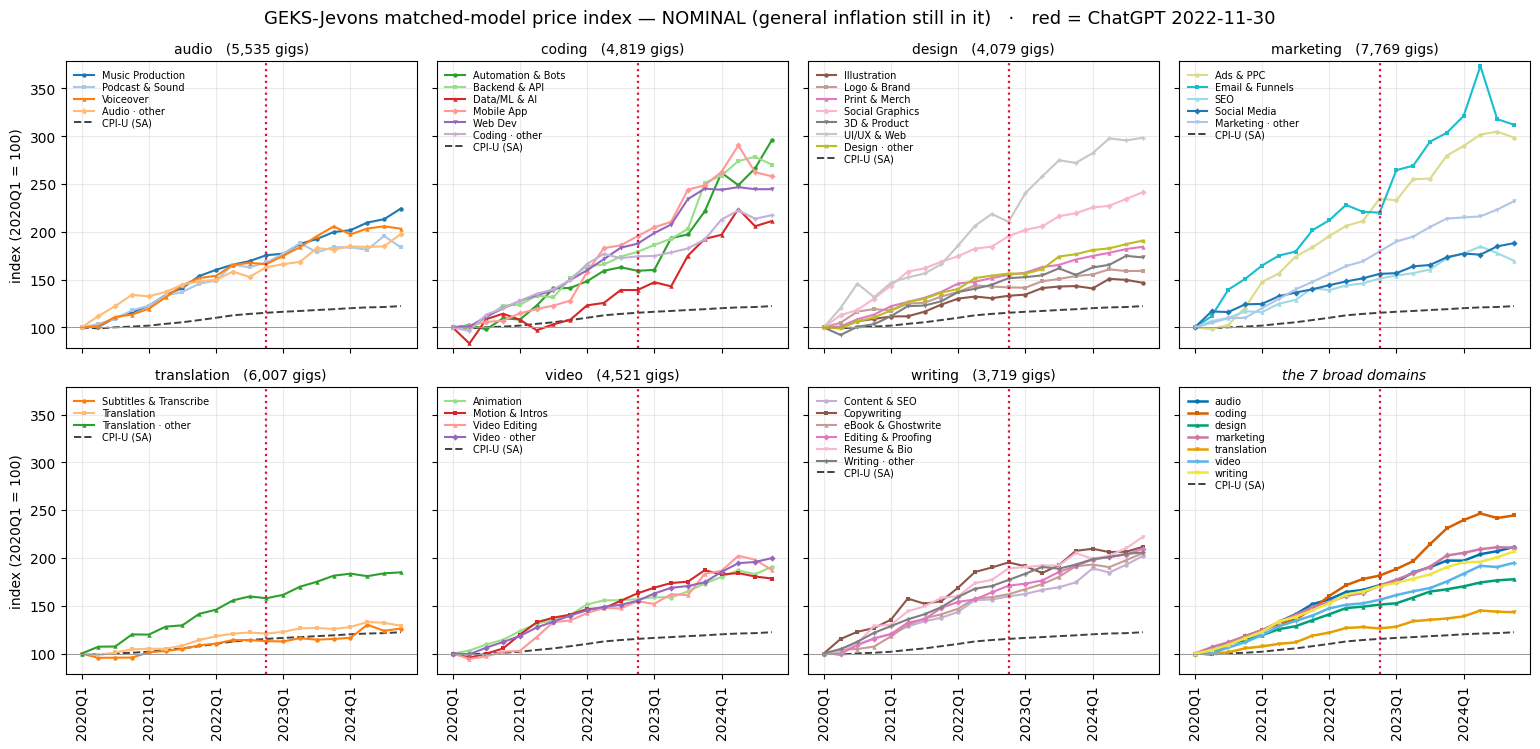

In [54]:
FAMS = tpd.CATS                # the notebook-wide domain order
QS = list(nom_n.index)

YLIM = (
    min(nom_n.min().min(), real_n.min().min()) - 5,
    max(nom_n.max().max(), real_n.max().max()) + 5
)

BGIGS = diag_b.set_index("category").gigs

MARKERS = ["o", "s", "^", "D", "v", "P", "X"]


# ============================================================
# COLORS FOR NARROW CATEGORIES
# ============================================================
# Each broad domain gets its own color family.
# Narrow categories within that domain get different shades.

TAB20_COLORS = list(plt.cm.tab20.colors)

NARROW_COLORS = {
    c: TAB20_COLORS[i % len(TAB20_COLORS)]
    for i, c in enumerate(NARROW)
}

# ============================================================
# COLORS FOR THE 7 BROAD DOMAINS
# ============================================================

DOMAIN_COLORS = {
    "audio":       "#0072B2",  # blue
    "coding":      "#D55E00",  # vermillion
    "design":      "#009E73",  # green
    "marketing":   "#CC79A7",  # purple/pink
    "translation": "#E69F00",  # orange
    "video":       "#56B4E9",  # light blue
    "writing":     "#F0E442",  # yellow
}


# ============================================================
# GEKS GRID
# ============================================================

def geks_grid(idx_narrow, idx_broad, title, ref, ref_label):
    """
    One panel per broad family holding its narrow-category lines,
    plus a final panel with the 7 broad domains.

    Axes are shared and YLIM is common to both charts, so
    nominal and real indices are read against the same ruler.
    """

    fig, axes = plt.subplots(
        2, 4,
        figsize=(15.5, 7.6),
        sharex=True,
        sharey=True
    )

    # ========================================================
    # NARROW CATEGORY PANELS
    # ========================================================

    for ax, fam in zip(axes.flat, FAMS):

        narrow_cats = [
            c for c in NARROW
            if LBL[c][1] == fam
        ]

        for i, c in enumerate(narrow_cats):

            ax.plot(
                QS,
                idx_narrow[c].values,
                lw=1.5,
                color=NARROW_COLORS[c],
                label=LBL[c][0],
                marker=MARKERS[i % len(MARKERS)],
                ms=3.2,
                mew=0
            )

        ax.set_title(
            f"{fam}   ({int(BGIGS.get(fam, 0)):,} gigs)",
            fontsize=10
        )


    # ========================================================
    # FINAL PANEL: 7 BROAD DOMAINS
    # ========================================================

    ax = axes.flat[len(FAMS)]

    for i, fam in enumerate(FAMS):

        if fam in idx_broad:

            ax.plot(
                QS,
                idx_broad[fam].values,
                lw=1.8,
                color=DOMAIN_COLORS[fam],
                label=fam,
                marker=MARKERS[i % len(MARKERS)],
                ms=3.2,
                mew=0
            )

    ax.set_title(
        "the 7 broad domains",
        fontsize=10,
        style="italic"
    )


    # ========================================================
    # FORMATTING FOR ALL PANELS
    # ========================================================

    for i, ax in enumerate(axes.flat):

        # CPI-U reference line
        ax.plot(
            QS,
            ref.values,
            "--",
            lw=1.4,
            color="0.25",
            zorder=1,
            label=ref_label
        )

        # Base index = 100
        ax.axhline(
            100,
            color="0.6",
            lw=0.7
        )

        # ChatGPT launch
        ax.axvline(
            LAUNCH,
            color="crimson",
            ls=":",
            lw=1.6
        )

        ax.grid(alpha=0.25)

        ax.legend(
            fontsize=7,
            frameon=False,
            loc="upper left",
            labelspacing=0.2
        )

        # X-axis labels only on bottom row
        if i // 4:
            ax.set_xticks(QS[::4])
            ax.set_xticklabels(
                QS[::4],
                rotation=90
            )

        # Y-axis labels only on left column
        if i % 4 == 0:
            ax.set_ylabel(
                f"index ({START_Q} = 100)"
            )


    # Common y-axis limits
    axes.flat[0].set_ylim(*YLIM)

    fig.suptitle(
        title,
        fontsize=13
    )

    fig.tight_layout()

    plt.show()


# ============================================================
# RUN NOMINAL GEKS PLOT
# ============================================================

geks_grid(
    nom_n,
    nom_b,
    "GEKS-Jevons matched-model price index — NOMINAL (general inflation still in it)"
    "   ·   red = ChatGPT 2022-11-30",
    cpi_line,
    "CPI-U (SA)"
)

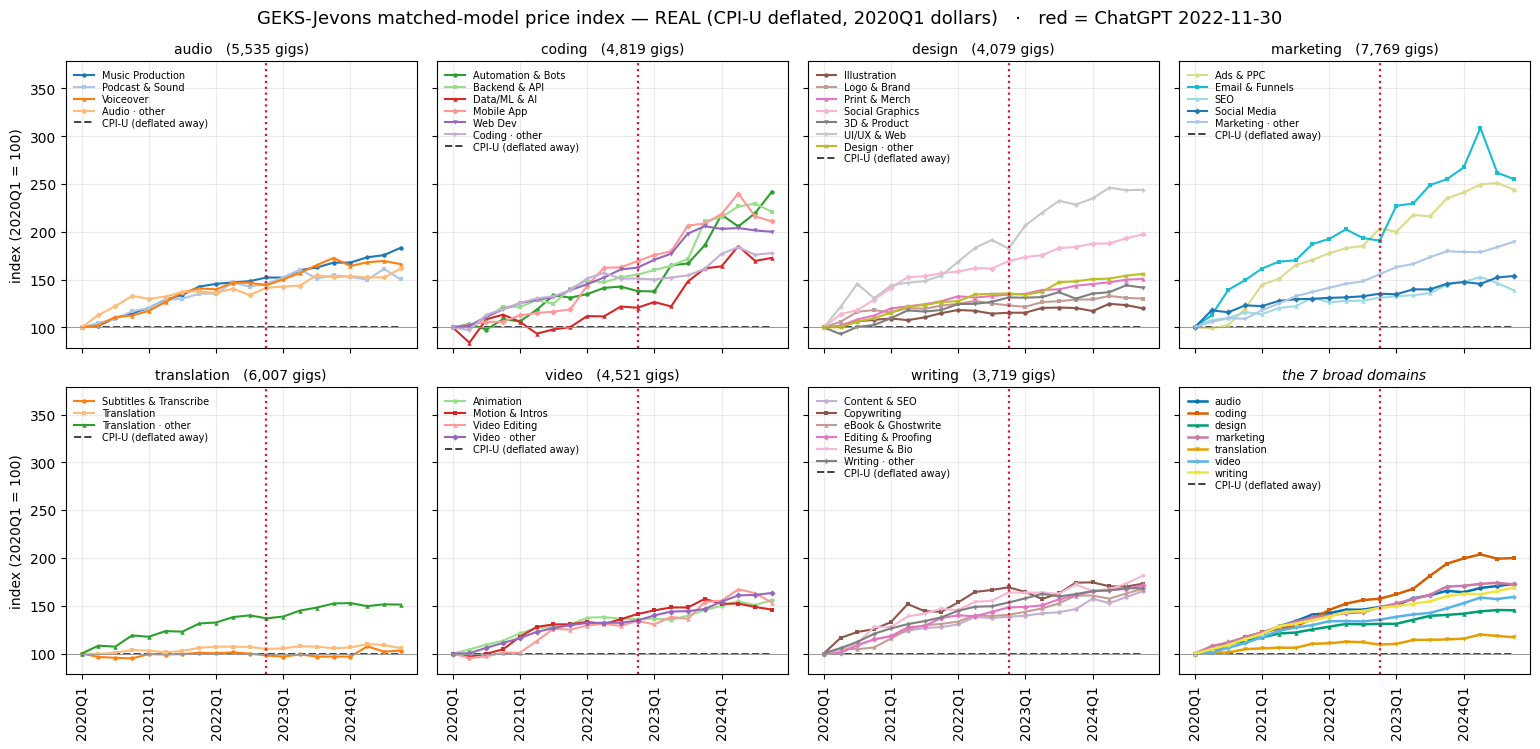

In [55]:
# The same index, the same panels, the same y-axis — divided by CPI-U. The dashed
# line is the deflator, now flat at 100 by construction: everything above it is a
# REAL price rise, and the drop from the chart above is the general price level.
geks_grid(real_n, real_b,
          f"GEKS-Jevons matched-model price index — REAL (CPI-U deflated, {START_Q} dollars)"
          "   ·   red = ChatGPT 2022-11-30",
          pd.Series(100.0, index=QS), "CPI-U (deflated away)")

In [ ]:
# End of window: how much of each category's climb was the dollar?
# The interval is the nominal gig-bootstrap band, which applies unchanged to the
# real level (the deflator carries no sampling error) — see the note above.
last = QS[-1]
lo   = 100 * (np.exp(np.log(real_n.loc[last] / 100) - 1.96 * se_n.loc[last]) - 1)
hi   = 100 * (np.exp(np.log(real_n.loc[last] / 100) + 1.96 * se_n.loc[last]) - 1)

summary = (pd.DataFrame({"gigs": diag_n.set_index("category").gigs,
                         "nominal_%": nom_n.loc[last] - 100,
                         "real_%": real_n.loc[last] - 100,
                         "real_lo_%": lo, "real_hi_%": hi})
             .loc[NARROW].round(1))
summary.insert(0, "family", [LBL[c][1] for c in summary.index])
summary.index = [LBL[c][0] for c in summary.index]
print(f"{START_Q} -> {last}, deflated by a CPI-U that rose "
      f"{cpi_line.iloc[-1] - 100:.1f}% over the same window")
summary.sort_values("real_%", ascending=False)

2020Q1 -> 2024Q4, deflated by a CPI-U that rose 22.3% over the same window


,family,gigs,nominal_%,real_%,real_lo_%,real_hi_%
Email & Funnels,marketing,656,212.0,155.1,81.0,259.4
Ads & PPC,marketing,818,198.5,144.1,98.6,199.9
UI/UX & Web,design,121,198.4,143.9,85.1,221.5
Automation & Bots,coding,343,196.2,142.1,71.7,241.3
Backend & API,coding,554,170.2,120.9,77.0,175.8
Mobile App,coding,307,158.0,110.9,64.5,170.6
Web Dev,coding,2446,144.6,100.0,83.7,117.8
Social Graphics,design,209,141.5,97.4,69.3,130.2
Marketing · other,marketing,2215,132.1,89.7,69.3,112.6
Music Production,audio,3445,124.3,83.4,70.1,97.8


In [ ]:
# "+145% for coding — is that real?" Three checks, no new data needed.
#
# 1. A Jevons bilateral is the MEAN of within-gig log price ratios. That
#    distribution is heavily right-skewed here (coding's 2020Q1->2024Q4 deciles run
#    0.00 / 0.69 / 2.07 at the 20th / 50th / 90th), and the mean of a skewed log
#    distribution sits well above the typical gig. Swapping in the median measures
#    that skew. It is a diagnostic, not an index — the charts stay mean-of-logs,
#    which is what Jevons means and what the papers report.
# 2. THE CHEAP END CARRIES THE LEVERAGE. A $5 listing that becomes $50 is +2.30 log
#    points and counts exactly as much in a bilateral as a $500 listing that becomes
#    $600 (+0.18). Listings entering at <= $10 reprice 2-3x faster per observed
#    quarter than dearer ones in every family, so the eroding $5 floor lifts every
#    line here. It does NOT explain coding's rank, though: translation had 64.5% of
#    its 2020 listings at or below $5 — the most of any family — and is the flattest
#    series on the chart.
# 3. The same estimator on the frame the site publishes ranks the domains
#    differently. Levels here are frame-dependent; treat the *shapes* as the result.
# 4. CHURN. Marketing's listings are the shortest-lived on the panel (median 9
#    quarters between first and last capture, against design's 33), so its index is
#    a relay of listings that overlap only briefly, and entry composition could be
#    carrying it. Re-running on gigs spanning >= 8 quarters answers that directly.
med_b = nrg.geks_variant(nrg.nested_by(wn, "category"), window_start=START_Q)
flr   = nrg.floor_shares(wn, by="category")

span = wn.groupby("gig_id").qi.agg(lambda s: s.max() - s.min() + 1)
long_lived = wn[wn.gig_id.map(span) >= 8]
nom_long = nrg.geks_variant(nrg.nested_by(long_lived, "category"),
                            agg=np.mean, window_start=START_Q)   # mean = plain Jevons

check = (pd.DataFrame({"nominal (plotted)": nom_b.loc[last],
                       "median-of-logs": med_b.loc[last],
                       "long-lived gigs only": nom_long.loc[last],
                       "real (plotted)": real_b.loc[last]})
           .join(flr).round(1).sort_values("nominal (plotted)", ascending=False))
display(check)
print(f"gigs: {wn.gig_id.nunique():,} -> {long_lived.gig_id.nunique():,} when restricted "
      f"to a span of 8+ quarters")

pub = pd.read_csv("data/pilot/panel-category-indices-geks.csv").set_index("quarter")
print(f"{last} nominal, same estimator, two sampling frames "
      f"(the published one is a different panel, not a different method):")
display(pd.DataFrame({"balanced frame (this notebook)": nom_b.loc[last].round(0),
                      "panel frame (step 21, published)": pub.loc[last].round(0)}))

,nominal (plotted),median-of-logs,long-lived gigs only,real (plotted),pc_le5_2020,pc_le5_2024,median_2020,median_2024
coding,244.5,173.7,244.3,199.9,26.8,6.6,15.0,50.0
audio,211.5,168.8,211.3,172.9,28.5,8.7,15.0,25.0
marketing,210.8,157.8,210.7,172.3,27.4,11.4,15.0,30.0
writing,206.8,166.1,207.0,169.1,23.8,11.0,20.0,30.0
video,194.9,147.6,194.9,159.3,23.0,10.1,20.0,30.0
design,177.7,140.7,177.9,145.3,18.8,11.3,20.0,25.0
translation,143.2,100.0,143.0,117.1,64.5,32.7,5.0,10.0


gigs: 36,449 -> 25,401 when restricted to a span of 8+ quarters
2024Q4 nominal, same estimator, two sampling frames (the published one is a different panel, not a different method):


,balanced frame (this notebook),"panel frame (step 21, published)"
audio,211.0,359.0
coding,245.0,212.0
design,178.0,127.0
marketing,211.0,282.0
translation,143.0,NaN
video,195.0,298.0
writing,207.0,206.0


### Reading the two charts

- **About a fifth of every nominal line was the dollar.** CPI-U rose 22.3% over the
  window, so the whole grid drops by roughly that much between the first chart and
  the second. Nothing turns negative — no fine-grained bucket got cheaper in
  constant dollars — and the ranking survives deflation intact, because the spread
  across categories (real +3% to +155%) dwarfs the deflator.
- **The two buckets that end flat in real terms are the translation pair.**
  Subtitles & Transcribe ends **+3.1% real [-12.1, +21.0]** and Translation
  **+5.5% [-3.0, +14.8]** — the only intervals in the table that cover zero. Every
  other bucket is a clear real increase, including the `translation · other`
  remainder at +51.2%. Translation is also the most AI-exposed cell on every
  crosswalk the project uses, so this is the one place the fine split puts a flat
  real price where the commoditisation story expects one.
- **The split locates the family story rather than overturning it.** Lines inside a
  panel mostly move together — the narrow buckets are a spread around their domain,
  not seven separate markets. Where they separate it is coding (Web Dev +100% real
  against Backend & API +121% and Automation & Bots +142%) and marketing (Email &
  Funnels +155% and Ads & PPC +144% against SEO +39%).
- **Still no break at the launch on either chart, at either level of aggregation.**
  The red line is not where anything turns. §8 puts that on a within-gig estimator
  and shows the pre-trend that makes this null hard to read as "nothing happened".
- **Read the shapes, not the levels — and coding least of all.** (i) *Skew.*
  Jevons averages **log** ratios and that distribution is heavily right-skewed here:
  coding's matched 2020Q1→2024Q4 changes run 0.00 / 0.69 / 2.07 at the 20th / 50th /
  90th percentile — the typical matched coding gig exactly doubled ($25→$50), while
  the top decile went eight-fold ($10→$80). The median-of-logs variant puts coding at
  **+74%** where the plotted mean-of-logs says **+145%**. This is not outlier
  contamination: 1% trimming moves coding by 0.5 index points. (ii) *The cheap end
  carries the leverage.* A $5→$50 listing is +2.30 log points against +0.18 for
  $500→$600, and listings entering at ≤$10 reprice 2–3× faster per observed quarter
  than dearer ones in every family — which lifts every line, but does not explain
  coding's rank, since translation is the most floor-heavy family (64.5% at or below
  $5 in 2020) and the flattest. (iii) *Frame dependence.* The same estimator on the
  panel frame the site publishes ranks coding **fourth** (+112%) behind audio
  (+259%), where this balanced frame ranks it first. So "coding rose fastest" is a
  property of this frame, not a finding. What survives all three is the within-family
  ordering and the nominal/real gap — including flat translation.
- **Marketing is high and it holds up — the checks that catch coding do not catch
  it.** Restricting to gigs observed across 8+ quarters moves the marketing level by
  0.04% (210.79 → 210.69), so it is not the short-lived listings; no single gig is
  worth more than 5% of the Ads & PPC level under a leave-one-out; the bilaterals are
  well populated (Ads & PPC matches a median of 61 gigs per quarter pair, minimum
  10); and marketing runs *higher* on the other frame (+282% there against +211%
  here), where coding's rank collapses. What it does have is width: Email & Funnels
  reads 373 at 2024Q2 against 321 and 318 either side, and its 95% band there is
  [284, 491] — the visible spike is inside the noise, not an event.
- The `· other` lines are keyword leftovers, not niches. In video and translation
  they hold most of the family's gigs, and in translation the remainder behaves
  nothing like the two named buckets — step 16's keyword lists were written for the
  recent monthly manifest and have never been tuned against this panel.

## 8. Event study — the same gigs before and after ChatGPT

$$\ln p_{i,t} \;=\; \alpha_i \;+\; \sum_{q \neq \text{2022Q3}} \delta_q \,\mathbf{1}[t=q] \;+\; \varepsilon_{i,t}$$

$\alpha_i$ is a **gig** fixed effect, $\delta_q$ a **quarter** effect, and 2022Q3
— the last fully pre-launch quarter — is the omitted base, so every $\delta_q$
reads as a log change relative to it. ChatGPT was released **2022-11-30**, inside
2022Q4, so 2022Q4 is the first treated quarter.

The sample is restricted to gigs observed **at least once before and at least once
after** the cut. That is what makes this a within-gig comparison: the path cannot
move because different gigs entered or left, which is exactly the objection that
sinks a naive before/after here, since entrants price above incumbents.

Gig effects are absorbed by within-gig demeaning rather than estimated, so 16k
dummies never touch memory. **SEs are clustered on gig.**

> **What this identifies.** There is no control group — every gig meets ChatGPT on
> the same date — so $\delta_q$ is the common time path of price on a fixed panel,
> net of gig level. Calling any part of it a causal effect requires assuming price
> would have been *flat* without the launch. The next cell tests that assumption
> directly, and on this data it fails: the series is already rising steeply before
> ChatGPT exists. Designs that do have a control group are steps 50/53/58 and the
> niche design of step 61; all failed, and the diagnosis in `plans/todo.md` is this
> same pre-trend. Read §8 as the picture of that problem, not as a way around it.

In [ ]:
bal = esm.balanced_sample(gq, cut=LAUNCH, window=(START_Q, END_Q))
print(f"window {START_Q}..{END_Q}")
print(f"  gigs seen pre-{LAUNCH} : {bal.attrs['n_pre']:,}")
print(f"  gigs seen post        : {bal.attrs['n_post']:,}")
print(f"  BALANCED (both sides) : {bal.attrs['n_balanced']:,}   <- the estimation sample")

tab, diag = esm.event_study(bal, base=BASE)
print(f"\n{diag['obs']:,} obs, {diag['gigs']:,} gigs, {diag['quarters']} quarters, base {diag['base']}")
tab[["quarter","coef","se","ci_lo","ci_hi","pct"]].round(4)

window 2020Q1..2024Q4
  gigs seen pre-2022Q4 : 29,451
  gigs seen post        : 23,126
  BALANCED (both sides) : 16,128   <- the estimation sample

168,467 obs, 16,128 gigs, 20 quarters, base 2022Q3


,quarter,coef,se,ci_lo,ci_hi,pct
0,2020Q1,-0.4363,0.0087,-0.4533,-0.4193,-35.3576
1,2020Q2,-0.4190,0.0082,-0.4351,-0.4029,-34.2276
2,2020Q3,-0.3582,0.0077,-0.3732,-0.3432,-30.1076
3,2020Q4,-0.3128,0.0072,-0.3270,-0.2987,-26.8637
4,2021Q1,-0.2676,0.0067,-0.2807,-0.2545,-23.4800
5,2021Q2,-0.2043,0.0061,-0.2163,-0.1923,-18.4778
6,2021Q3,-0.1709,0.0055,-0.1817,-0.1602,-15.7120
7,2021Q4,-0.1154,0.0051,-0.1254,-0.1054,-10.8988
8,2022Q1,-0.0642,0.0046,-0.0731,-0.0552,-6.2169
9,2022Q2,-0.0174,0.0036,-0.0244,-0.0104,-1.7259


pre-trend fitted on 11 pre-launch quarters:
  slope +0.0469 log points/quarter  (t = 42.0)
  gap at 2024Q4: -0.2134 log points (-19.2%) vs the extrapolated pre-trend


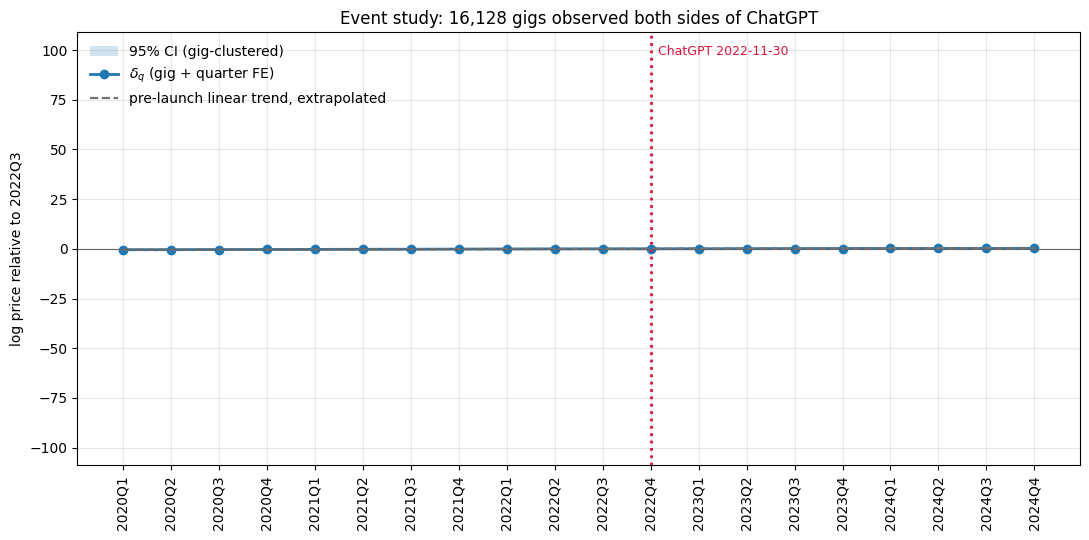

In [ ]:
pt = esm.pretrend_test(tab, cut=LAUNCH)
print(f"pre-trend fitted on {pt['pre_quarters']} pre-launch quarters:")
print(f"  slope {pt['slope']:+.4f} log points/quarter  (t = {pt['t']:.1f})")
print(f"  gap at {tab.quarter.iloc[-1]}: {pt['gap_last']:+.4f} log points "
      f"({100*np.expm1(pt['gap_last']):+.1f}%) vs the extrapolated pre-trend")

t = pt["table"]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhspan(-99, 99, xmin=0, xmax=0, color="none")
ax.fill_between(t.quarter, t.ci_lo, t.ci_hi, alpha=.2, label="95% CI (gig-clustered)")
ax.plot(t.quarter, t.coef, "o-", lw=2, color="C0", label=r"$\delta_q$ (gig + quarter FE)")
ax.plot(t.quarter, t.pretrend, "--", lw=1.6, color="0.45",
        label="pre-launch linear trend, extrapolated")
ax.axvline(LAUNCH, color="crimson", ls=":", lw=2)
ax.axhline(0, color="0.4", lw=.8)
ax.annotate("ChatGPT 2022-11-30", xy=(LAUNCH, ax.get_ylim()[1]), xytext=(5,-16),
            textcoords="offset points", color="crimson", fontsize=9)
ax.set_ylabel(f"log price relative to {BASE}")
ax.set_title(f"Event study: {bal.attrs['n_balanced']:,} gigs observed both sides of ChatGPT")
ax.legend(frameon=False, loc="upper left"); ax.grid(alpha=.3)
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

In [ ]:
# Same design run inside each category — does any one of them break at the launch?
rows = []
for c in tpd.CATS:
    sub = esm.balanced_sample(gq[gq.category == c], cut=LAUNCH, window=(START_Q, END_Q))
    if sub.attrs["n_balanced"] < 200:
        rows.append({"category": c, "gigs": sub.attrs["n_balanced"], "note": "too thin"}); continue
    ct, _ = esm.event_study(sub, base=BASE)
    cpt   = esm.pretrend_test(ct, cut=LAUNCH)
    rows.append({"category": c, "gigs": sub.attrs["n_balanced"],
                 "pre_slope": round(cpt["slope"], 4), "pre_t": round(cpt["t"], 1),
                 "post_gap": round(cpt["gap_last"], 4),
                 "cum_2024Q4": round(float(ct.coef.iloc[-1]), 4)})
pd.DataFrame(rows)

,category,gigs,pre_slope,pre_t,post_gap,cum_2024Q4
0,audio,2271,0.0528,28.5,-0.2632,0.2426
1,coding,2477,0.0614,26.4,-0.2437,0.3101
2,design,2773,0.0404,36.6,-0.2159,0.1664
3,marketing,2181,0.0514,31.1,-0.2342,0.2571
4,translation,1674,0.0239,16.9,-0.0780,0.1313
5,video,2371,0.0458,21.0,-0.2019,0.2460
6,writing,2381,0.0518,40.1,-0.2640,0.2269


### Reading the result

Three things to take from §8, in the order they should change your mind.

1. **The pre-trend is the headline.** Prices rise ~4.7 log points *per quarter*
   through 2020Q1–2022Q3, and a straight line fits those 11 quarters to within
   ±0.02. Whatever is moving this market was moving it hard for two years before
   ChatGPT shipped. Any claim of the form "prices did X after the launch" has to
   beat that line, not zero.

2. **There is no break at the launch.** 2022Q4 and 2023Q1 sit on the pre-trend;
   nothing steps, in either direction, at the date. This reproduces the papers'
   central null on a different estimator than the ones they use.

3. **The post-period deceleration is real but weakly identified.** The series keeps
   rising and ends 2024Q4 about 0.21 log points (≈19%) *below* where the pre-trend
   would have put it. That is a large number and it is the most interesting thing
   on the chart — but it rests on extrapolating a linear trend eight quarters past
   its last data point, and no price series grows exponentially forever. Mean
   reversion produces the same picture with no treatment at all, and step 49 shows
   that exact failure mode on this data. Treat it as a description of the shape,
   not an effect, until it survives a control group.

The honest one-line summary: **prices were rising steeply before ChatGPT, did not
break at it, and rose more slowly afterwards for reasons this design cannot
attribute.**

## 9. Composite pre-trend vs post-ChatGPT (AP)

Added on the `mockup` branch by a second author. It builds a **composite** from
the broad-domain GEKS levels — the geometric mean across the seven domains — fits
a log-linear trend on the pre-launch quarters only, and reads the post-period as a
gap against that extrapolation. §8 does the same thing on a within-gig estimator
with gig fixed effects; this does it on the index. The caveat in §8 applies here
with more force, since an eight-quarter extrapolation of a log-linear trend is the
whole counterfactual.

`geks_df` is the broad-domain nominal table §7 builds (`nom_b`), aliased in the
§7 build cell so these cells keep running after §7 moved to 35 categories.
The last cell needs `statsmodels`, which is not a project dependency — it is
guarded so the notebook still runs end to end without it.


In [ ]:
# ============================================================
# PRE-TREND VS POST-CHATGPT
# Using the existing GEKS-Jevons results
# ============================================================

g = geks_df.copy()

# Create an overall index across categories
# Geometric mean = appropriate for combining price relatives
g["composite"] = np.exp(
    np.log(g).mean(axis=1)
)

# Turn quarter index into a normal column
g = g.reset_index()

# Find the actual quarter column
g = g.rename(columns={g.columns[0]: "quarter"})

# Convert quarter to Period
g["quarter_period"] = pd.PeriodIndex(
    g["quarter"],
    freq="Q"
)

# Time index
g["time_index"] = np.arange(len(g))

# ChatGPT launch
chatgpt = pd.Period("2022Q4", freq="Q")

# ------------------------------------------------------------
# Fit trend ONLY before ChatGPT
# ------------------------------------------------------------

pre = g[
    g["quarter_period"] < chatgpt
].copy()

# Log-linear trend
coef = np.polyfit(
    pre["time_index"],
    np.log(pre["composite"]),
    1
)

# Predict what prices would have looked like
# if the pre-ChatGPT trend had continued
g["pretrend_log"] = np.polyval(
    coef,
    g["time_index"]
)

g["pretrend_index"] = np.exp(
    g["pretrend_log"]
)

# Difference between observed and extrapolated trend
g["gap_pct"] = (
    g["composite"] /
    g["pretrend_index"] - 1
) * 100

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(
    g[
        [
            "quarter",
            "composite",
            "pretrend_index",
            "gap_pct"
        ]
    ].round(2)
)

,quarter,composite,pretrend_index,gap_pct
0,2020Q1,100.00,98.96,1.05
1,2020Q2,101.91,103.87,-1.89
2,2020Q3,108.55,109.02,-0.43
3,2020Q4,114.26,114.43,-0.14
4,2021Q1,119.88,120.10,-0.18
5,2021Q2,127.56,126.06,1.19
6,2021Q3,132.52,132.31,0.16
7,2021Q4,140.36,138.87,1.07
8,2022Q1,147.11,145.76,0.93
9,2022Q2,154.13,152.99,0.75


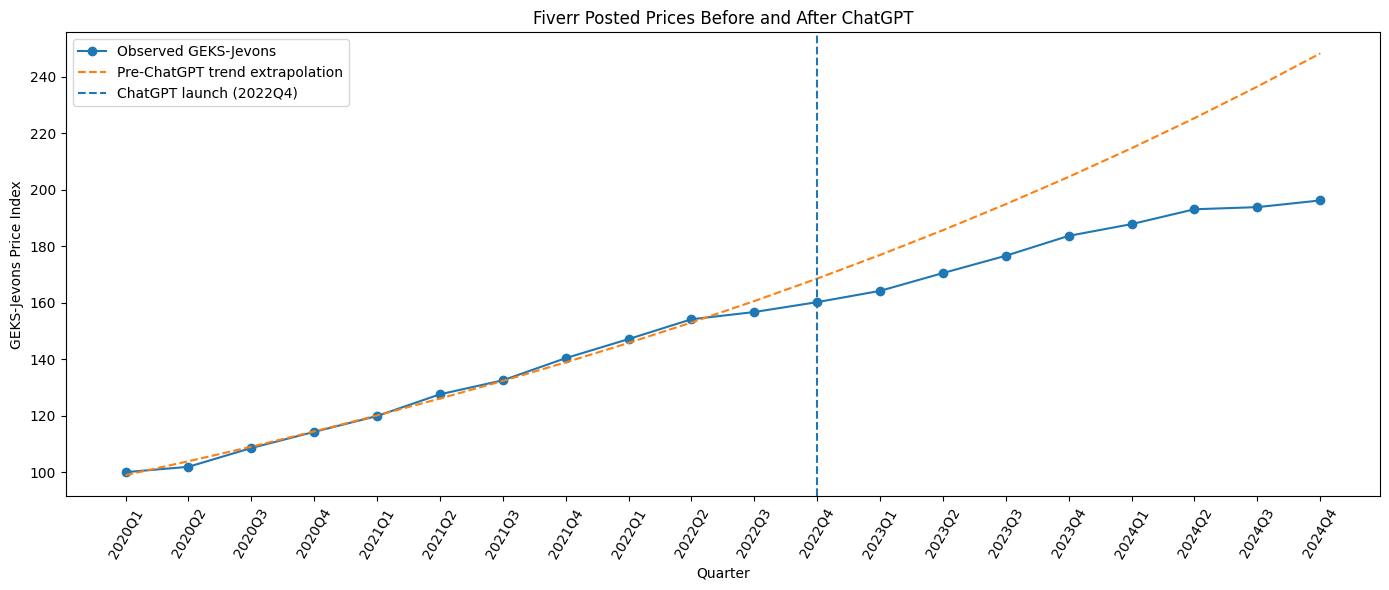

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    g["quarter"],
    g["composite"],
    marker="o",
    label="Observed GEKS-Jevons"
)

plt.plot(
    g["quarter"],
    g["pretrend_index"],
    linestyle="--",
    label="Pre-ChatGPT trend extrapolation"
)

# ChatGPT launch
chatgpt_position = list(
    g["quarter"]
).index("2022Q4")

plt.axvline(
    chatgpt_position,
    linestyle="--",
    label="ChatGPT launch (2022Q4)"
)

plt.xlabel("Quarter")
plt.ylabel("GEKS-Jevons Price Index")
plt.title(
    "Fiverr Posted Prices Before and After ChatGPT"
)

plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()
plt.show()

Pre-ChatGPT quarters: 2020Q1 to 2022Q3
Post-ChatGPT quarters: 2022Q4 to 2024Q4
Pre observations: 11
Post observations: 9

PRE-CHATGPT TREND
Slope: 0.04840 log points / quarter
95% CI: [0.04562, 0.05118]
Approx. quarterly growth: 4.96%
R²: 0.994

POST-CHATGPT TREND
Slope: 0.02698 log points / quarter
95% CI: [0.02226, 0.03170]
Approx. quarterly growth: 2.73%
R²: 0.963

CHANGE IN GROWTH RATE
Pre-ChatGPT slope:  0.04840
Post-ChatGPT slope: 0.02698
Difference:         -0.02142
95% CI:             [-0.02602, -0.01682]
t-statistic:        -9.136
p-value:            0.0000000000
Relative slowdown:  44.3%

FORMAL SLOPE-CHANGE TEST
Slope-change coefficient: -0.02142
95% CI: [-0.02621, -0.01663]
p-value: 0.0000
RESULT: The change in slope is statistically significant.


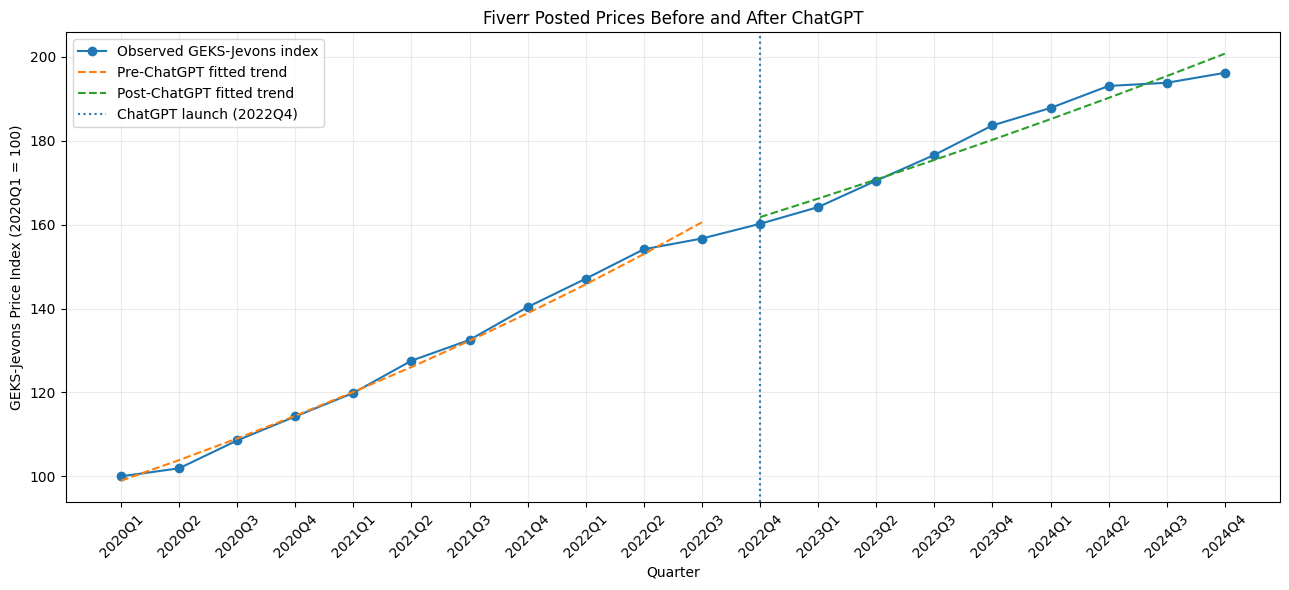

,Period,Slope_log_points_per_quarter,Approx_growth_percent_per_quarter,CI_low,CI_high
0,Pre-ChatGPT,0.0484,4.9589,0.0456,0.0512
1,Post-ChatGPT,0.0270,2.7345,0.0223,0.0317



PAPER-READY INTERPRETATION
Before ChatGPT, the GEKS-Jevons price index increased by approximately 0.048 log points per quarter (about 4.96% per quarter). After ChatGPT, the corresponding trend was 0.027 log points per quarter (about 2.73% per quarter). The difference in slopes was -0.021 log points per quarter (p=0.00000000000000000000).


In [ ]:
try:
    import statsmodels.api as sm
except ImportError:
    sm = None
    print('SKIP — statsmodels not installed '
          '(pip install --user statsmodels); §8 runs the same test '
          'with gig fixed effects and gig-clustered SEs)')

if sm is not None:
    # ============================================================
    # PRE- VS POST-CHATGPT PRICE GROWTH ANALYSIS
    # Using the GEKS-Jevons composite index
    # ============================================================

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import statsmodels.api as sm
    import statsmodels.formula.api as smf

    # ------------------------------------------------------------
    # 1. PREPARE THE GEKS DATA
    # ------------------------------------------------------------

    g = geks_df.copy()

    # Make sure quarter is a proper quarterly Period
    g.index = pd.PeriodIndex(g.index.astype(str), freq="Q")

    # If your GEKS dataframe contains categories, create the
    # composite GEKS index as the geometric mean across categories.
    category_cols = [c for c in tpd.CATS if c in g.columns]

    g["composite"] = np.exp(
        np.log(g[category_cols]).mean(axis=1)
    )

    # Remove quarters where composite cannot be calculated
    g = g.dropna(subset=["composite"]).copy()

    # Time index: one unit = one quarter
    g["quarter"] = g.index
    g["time"] = np.arange(len(g))

    # Log price index
    g["log_geks"] = np.log(g["composite"])


    # ------------------------------------------------------------
    # 2. DEFINE PRE- AND POST-CHATGPT PERIODS
    # ------------------------------------------------------------

    CHATGPT_Q = pd.Period("2022Q4", freq="Q")
    PRE_LAST_Q = pd.Period("2022Q3", freq="Q")

    pre = g[g.index <= PRE_LAST_Q].copy()
    post = g[g.index >= CHATGPT_Q].copy()

    print("Pre-ChatGPT quarters:", pre.index.min(), "to", pre.index.max())
    print("Post-ChatGPT quarters:", post.index.min(), "to", post.index.max())
    print("Pre observations:", len(pre))
    print("Post observations:", len(post))


    # ------------------------------------------------------------
    # 3. ESTIMATE PRE-CHATGPT TREND
    # ------------------------------------------------------------

    X_pre = sm.add_constant(pre["time"])
    model_pre = sm.OLS(pre["log_geks"], X_pre).fit()

    pre_slope = model_pre.params["time"]
    pre_se = model_pre.bse["time"]

    pre_ci = model_pre.conf_int().loc["time"]

    print("\n" + "="*60)
    print("PRE-CHATGPT TREND")
    print("="*60)

    print(f"Slope: {pre_slope:.5f} log points / quarter")
    print(f"95% CI: [{pre_ci[0]:.5f}, {pre_ci[1]:.5f}]")
    print(f"Approx. quarterly growth: {(np.exp(pre_slope)-1)*100:.2f}%")
    print(f"R²: {model_pre.rsquared:.3f}")


    # ------------------------------------------------------------
    # 4. ESTIMATE POST-CHATGPT TREND
    # ------------------------------------------------------------

    X_post = sm.add_constant(post["time"])
    model_post = sm.OLS(post["log_geks"], X_post).fit()

    post_slope = model_post.params["time"]
    post_se = model_post.bse["time"]

    post_ci = model_post.conf_int().loc["time"]

    print("\n" + "="*60)
    print("POST-CHATGPT TREND")
    print("="*60)

    print(f"Slope: {post_slope:.5f} log points / quarter")
    print(f"95% CI: [{post_ci[0]:.5f}, {post_ci[1]:.5f}]")
    print(f"Approx. quarterly growth: {(np.exp(post_slope)-1)*100:.2f}%")
    print(f"R²: {model_post.rsquared:.3f}")


    # ------------------------------------------------------------
    # 5. DIFFERENCE IN SLOPES
    # ------------------------------------------------------------

    slope_difference = post_slope - pre_slope

    # Approximate SE assuming independent slope estimates
    diff_se = np.sqrt(pre_se**2 + post_se**2)

    t_stat = slope_difference / diff_se

    from scipy.stats import norm

    p_value = 2 * (1 - norm.cdf(abs(t_stat)))

    diff_ci_low = slope_difference - 1.96 * diff_se
    diff_ci_high = slope_difference + 1.96 * diff_se

    print("\n" + "="*60)
    print("CHANGE IN GROWTH RATE")
    print("="*60)

    print(f"Pre-ChatGPT slope:  {pre_slope:.5f}")
    print(f"Post-ChatGPT slope: {post_slope:.5f}")
    print(f"Difference:         {slope_difference:.5f}")
    print(f"95% CI:             [{diff_ci_low:.5f}, {diff_ci_high:.5f}]")
    print(f"t-statistic:        {t_stat:.3f}")
    print(f"p-value:            {p_value:.10f}")

    if pre_slope != 0:
        slowdown_pct = (pre_slope - post_slope) / abs(pre_slope) * 100
        print(f"Relative slowdown:  {slowdown_pct:.1f}%")


    # ------------------------------------------------------------
    # 6. SINGLE REGRESSION TESTING WHETHER THE SLOPE CHANGED
    # ------------------------------------------------------------
    #
    # This is the cleaner statistical test.
    #
    # log(price) =
    #       intercept
    #       + time
    #       + post
    #       + time × post
    #
    # The interaction coefficient tells us whether the slope
    # changed after ChatGPT.
    # ------------------------------------------------------------

    g["post_chatgpt"] = (g.index >= CHATGPT_Q).astype(int)

    # Center time at the ChatGPT launch so interpretation is easier
    chatgpt_time = g.loc[CHATGPT_Q, "time"] if CHATGPT_Q in g.index else g["time"].min()

    g["time_centered"] = g["time"] - chatgpt_time

    interaction_model = smf.ols(
        "log_geks ~ time_centered + post_chatgpt + time_centered:post_chatgpt",
        data=g
    ).fit()

    interaction = interaction_model.params["time_centered:post_chatgpt"]
    interaction_ci = interaction_model.conf_int().loc[
        "time_centered:post_chatgpt"
    ]

    print("\n" + "="*60)
    print("FORMAL SLOPE-CHANGE TEST")
    print("="*60)

    print(f"Slope-change coefficient: {interaction:.5f}")
    print(f"95% CI: [{interaction_ci[0]:.5f}, {interaction_ci[1]:.5f}]")
    print(f"p-value: {interaction_model.pvalues['time_centered:post_chatgpt']:.4f}")

    if interaction_model.pvalues["time_centered:post_chatgpt"] < 0.05:
        print("RESULT: The change in slope is statistically significant.")
    else:
        print("RESULT: The change in slope is NOT statistically significant.")


    # ------------------------------------------------------------
    # 7. CREATE FITTED TREND LINES
    # ------------------------------------------------------------

    g["pre_fitted"] = model_pre.predict(
        sm.add_constant(g["time"], has_constant="add")
    )

    g["post_fitted"] = model_post.predict(
        sm.add_constant(g["time"], has_constant="add")
    )

    # Convert fitted log values back to index levels
    g["pre_fitted_index"] = np.exp(g["pre_fitted"])
    g["post_fitted_index"] = np.exp(g["post_fitted"])


    # ------------------------------------------------------------
    # 8. PLOT ACTUAL GEKS + PRE/POST TRENDS
    # ------------------------------------------------------------

    plt.figure(figsize=(13, 6))

    plt.plot(
        g.index.astype(str),
        g["composite"],
        marker="o",
        label="Observed GEKS-Jevons index"
    )

    plt.plot(
        pre.index.astype(str),
        g.loc[pre.index, "pre_fitted_index"],
        linestyle="--",
        label="Pre-ChatGPT fitted trend"
    )

    plt.plot(
        post.index.astype(str),
        g.loc[post.index, "post_fitted_index"],
        linestyle="--",
        label="Post-ChatGPT fitted trend"
    )

    # ChatGPT launch marker
    launch_position = list(g.index.astype(str)).index(str(CHATGPT_Q))

    plt.axvline(
        launch_position,
        linestyle=":",
        label="ChatGPT launch (2022Q4)"
    )

    plt.title("Fiverr Posted Prices Before and After ChatGPT")
    plt.xlabel("Quarter")
    plt.ylabel("GEKS-Jevons Price Index (2020Q1 = 100)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


    # ------------------------------------------------------------
    # 9. SUMMARY TABLE
    # ------------------------------------------------------------

    summary = pd.DataFrame({
        "Period": ["Pre-ChatGPT", "Post-ChatGPT"],
        "Slope_log_points_per_quarter": [
            pre_slope,
            post_slope
        ],
        "Approx_growth_percent_per_quarter": [
            (np.exp(pre_slope)-1)*100,
            (np.exp(post_slope)-1)*100
        ],
        "CI_low": [
            pre_ci[0],
            post_ci[0]
        ],
        "CI_high": [
            pre_ci[1],
            post_ci[1]
        ]
    })

    display(summary.round(4))

    print("\n" + "="*60)
    print("PAPER-READY INTERPRETATION")
    print("="*60)

    print(
        f"Before ChatGPT, the GEKS-Jevons price index increased by "
        f"approximately {pre_slope:.3f} log points per quarter "
        f"(about {(np.exp(pre_slope)-1)*100:.2f}% per quarter). "
        f"After ChatGPT, the corresponding trend was "
        f"{post_slope:.3f} log points per quarter "
        f"(about {(np.exp(post_slope)-1)*100:.2f}% per quarter). "
        f"The difference in slopes was {slope_difference:.3f} "
        f"log points per quarter (p={p_value:.20f})."
    )

## 10. The price model — task value, inflation, reputation, and AI exposure

The question this section answers, in the order it was posed: **once you take out
general inflation, what the work is intrinsically worth, and the seller's
reputation, does what is left move with AI exposure after ChatGPT?**

$$\ln p^{\text{real}}_{i,t} \;=\; \alpha_i \;+\; \delta_t \;+\; \beta_1 \ln(1+\text{reviews})_{i,t} \;+\; \beta_2\,\text{rating}_{i,t} \;+\; \gamma\,\bigl(\text{Exposure}_c \times \text{Post}_t\bigr) \;+\; \varepsilon_{i,t}$$

Everything is **imported from `code/76-price-model.py`** — the panel builder, the
fixed-effect estimator, the exposure loaders and the battery — so the notebook and
`runs/price-model/model.md` are the same fit, not two implementations that happen
to agree.

**Inflation** is removed before estimation, not controlled for: prices are divided by
CPI-U (SA, quarterly mean) into 2020Q1 dollars, the identical definition
`code/23-real-index.py` uses for the published real series and §7 uses for its second
chart.

**Task value** $x$ — what this particular piece of work is intrinsically worth — is
time-invariant by construction, so it *is* the gig fixed effect $\alpha_i$. It is
absorbed during fitting and recovered afterwards as the per-gig intercept. No
observable in this data measures task value, and putting a proxy where a fixed effect
belongs would be the worse error; the first chart below shows how much variation
would be mis-assigned if we tried.

**Reputation** $z$ is the pair $\ln(1+\text{reviews})$ — the treadmill steps 22 and 27
measured — and `rating` beside it. Reviews are cumulative, so the quarter's maximum is
the level at quarter end.

**The AI term.** $\text{Exposure}_c$ is constant within a category, so it dies in the
gig effect, and $\text{Post}_t$ dies in the quarter effect; only the interaction is
identified. That makes $\gamma$ a difference-in-differences in everything but name,
and it inherits every objection that killed the earlier ones.

> **Which exposure measure, and why the order matters.** Two are available and they
> disagree, so the choice cannot be made after seeing the result.
> **Primary** is `data/exposure-ranking.csv` — Eloundou et al. human-annotated
> occupation exposure, **pre-registered** in `plans/active/transaction-volume-prereg.md`.
> It is the weaker measure (constant per category) but it is the one locked before any
> outcome was seen. **Secondary** is step 75's share of newly archived gigs whose title
> advertises AI, measured over 1.77M gigs — better in every technical respect, and it
> ranks the categories *nearly opposite* to the pre-registration. Promoting it after
> seeing an outcome is exactly the specification search a prereg exists to stop, so it
> runs last, labelled exploratory, and §10.5 is mostly about why its very large
> coefficient is not a finding.

The sample is the same balance §8 imposes — a gig must be seen **both before and after**
2022Q4 — so $\gamma$ is identified off repricing within surviving gigs, never off entry
and exit. SEs are clustered on gig throughout; step 22 shipped an unclustered SE that
was 1.93× too small, and §10.4E prices that error again here.

### 10.1 The panel

In [ ]:
pm = _load("pm", "code/76-price-model.py")    # the model itself — imported, not rewritten

PM_START, PM_END = "2019Q4", "2024Q4"   # opens where reviews+rating are populated, closes
                                        # at the archive ceiling (the 403 cliff, see todo)

# build_panel is step 76's, not step 64's: same is_gig / known-category / 0<price<=10000
# filter, plus the two reputation columns and the CPI-U deflation to 2020Q1 dollars.
gqm = pm.build_panel(PRICES, CATEGORY_CSV)

lo, hi = pm.q_to_int(PM_START), pm.q_to_int(PM_END)
win = gqm[(gqm.qi >= lo) & (gqm.qi <= hi)]
d   = win[win.reviews.notna() & win.rating.notna() & (win.real > 0)].copy()

# the same balance the §8 event study imposes: a gig must be seen on BOTH sides of the
# launch, or the AI term would be identified off entry and exit rather than off repricing
CUT  = pm.q_to_int(pm.CHATGPT_LAUNCH)
both = set(d.gig_id[d.qi < CUT]) & set(d.gig_id[d.qi >= CUT])
d    = d[d.gig_id.isin(both)].sort_values(["gig_id", "qi"]).reset_index(drop=True)

EXPO  = pd.read_csv("data/exposure-ranking.csv").set_index("category").exposure_primary
e_vec = d.category.map(EXPO).to_numpy(float)
SPREAD = EXPO.max() - EXPO.min()

print(f"{len(win):,} in-window rows -> {len(d):,} gig-quarter observations, "
      f"{d.gig_id.nunique():,} gigs, {PM_START}–{PM_END}")
print(f"dropped {len(win)-len(d):,}: no rating/review count, or not seen both sides of "
      f"{pm.CHATGPT_LAUNCH}")
print(f"exposure (Eloundou, pre-registered) {EXPO.min():.2f} {EXPO.idxmin()} .. "
      f"{EXPO.max():.2f} {EXPO.idxmax()}  — spread {SPREAD:.2f}")

(d.groupby("category")
   .agg(gigs=("gig_id", "nunique"), obs=("gig_id", "size"),
        median_real=("real", "median"), median_reviews=("reviews", "median"))
   .assign(exposure=EXPO).sort_values("exposure", ascending=False).round(2))

249,213 in-window rows -> 169,337 gig-quarter observations, 15,676 gigs, 2019Q4–2024Q4
dropped 79,876: no rating/review count, or not seen both sides of 2022Q4
exposure (Eloundou, pre-registered) 0.25 audio .. 0.84 translation  — spread 0.59


,gigs,obs,median_real,median_reviews,exposure
category,,,,,
translation,1598,12590,5.05,153.0,0.84
writing,2341,30334,24.09,229.0,0.69
marketing,2033,16156,27.25,84.0,0.62
coding,2446,26295,26.63,141.0,0.59
design,2718,36623,21.67,388.0,0.51
video,2305,25887,24.78,121.0,0.40
audio,2235,21452,20.99,139.0,0.25


### 10.2 Deflation, reputation and task value

In [ ]:
# ---- 1. deflation: how much of the posted price is just the dollar? -------------
nom, real = np.log(d.price).mean(), np.log(d.real).mean()
print(f"mean ln price  {nom:.4f} nominal -> {real:.4f} real "
      f"({100*np.expm1(real-nom):+.1f}%)   — CPI-U, {pm.CPI_BASE} dollars\n")

# ---- 2. reputation (z) and task value (x), no AI term yet -----------------------
y, X, names, g = pm.design(d, None)          # gig FE + quarter FE + ln(1+reviews) + rating
tab0, fit0 = pm.fe_ols(y, X, g, names)       # gig FE absorbed by demeaning, SEs on gig

b_rev = float(tab0.loc[tab0.term == "ln(1+reviews)", "coef"].iloc[0])
print(tab0[tab0.term.isin(["ln(1+reviews)", "rating"])].to_string(index=False))
print(f"\nreputation: a DOUBLING of cumulative reviews carries "
      f"{100*np.expm1(b_rev*np.log(2)):+.2f}% in real price")
print(f"            step 22/27 measured +7.7% nominal on different panels — same treadmill")
print(f"within-gig R2 {fit0['within_r2']:.4f}   residual SD {fit0['resid_sd']:.4f} log points")

# task value = the gig intercept, recovered after fitting. Time-invariant by
# construction, so a fixed effect is its only honest home in this data.
gid  = pd.factorize(d.gig_id)[0]
xval = (pd.DataFrame({"gig_id": d.gig_id.to_numpy()[np.unique(gid, return_index=True)[1]],
                      "x": fit0["alpha"]})
          .merge(d[["gig_id", "category"]].drop_duplicates(), on="gig_id"))
print(f"\ntask value x: SD {xval.x.std():.3f} log points across {len(xval):,} gigs "
      f"— an order more variation than anything time-varying above")

mean ln price  3.2929 nominal -> 3.1858 real (-10.2%)   — CPI-U, 2020Q1 dollars

         term     coef       se         t
ln(1+reviews) 0.102115 0.003936 25.946333
       rating 0.098978 0.035165  2.814662

reputation: a DOUBLING of cumulative reviews carries +7.33% in real price
            step 22/27 measured +7.7% nominal on different panels — same treadmill
within-gig R2 0.1348   residual SD 0.3476 log points

task value x: SD 1.249 log points across 15,676 gigs — an order more variation than anything time-varying above


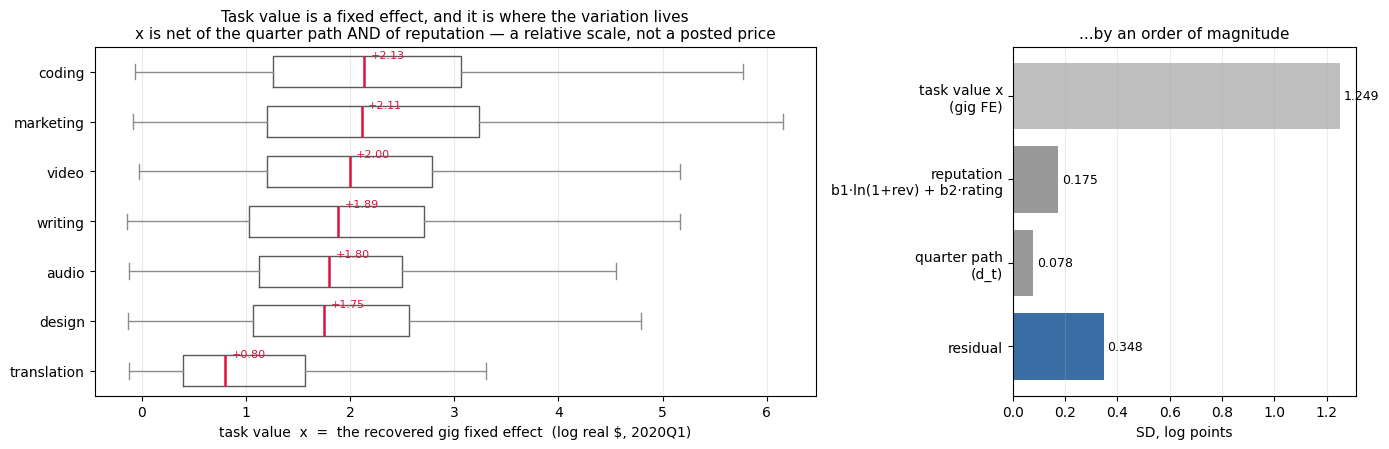

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.6),
                               gridspec_kw={"width_ratios": [2.1, 1]})

order = xval.groupby("category").x.median().sort_values().index.tolist()
axL.boxplot([xval.x[xval.category == c].values for c in order],
            orientation="horizontal", showfliers=False, widths=.62,
            medianprops=dict(color="crimson", lw=1.8),
            boxprops=dict(color="0.35"), whiskerprops=dict(color="0.55"),
            capprops=dict(color="0.55"))
for i, c in enumerate(order, start=1):
    m = xval.x[xval.category == c].median()
    axL.text(m + .06, i + .28, f"{m:+.2f}", fontsize=8, color="crimson")
axL.set_yticks(range(1, len(order) + 1)); axL.set_yticklabels(order)   # not `labels=`,
                                                       # which matplotlib 3.9 renamed
axL.set_xlabel("task value  x  =  the recovered gig fixed effect  (log real $, 2020Q1)")
axL.set_title("Task value is a fixed effect, and it is where the variation lives\n"
              "x is net of the quarter path AND of reputation — a relative scale, "
              "not a posted price", fontsize=11)
axL.grid(axis="x", alpha=.25)

# why x belongs in the fixed effect rather than in a proxy: it dwarfs everything
# the model can actually observe moving within a gig.
parts = {"task value x\n(gig FE)": xval.x.std(),
         "reputation\nb1·ln(1+rev) + b2·rating": float(np.std(
             X[:, -2] * b_rev + X[:, -1] * float(tab0.loc[tab0.term == "rating", "coef"].iloc[0]))),
         "quarter path\n(d_t)": float(np.std(X[:, :len(names)-2] @
             tab0.coef.to_numpy()[:len(names)-2])),
         "residual": fit0["resid_sd"]}
axR.barh(list(parts)[::-1], list(parts.values())[::-1],
         color=["0.75", "0.6", "0.6", "#3b6ea5"][::-1])
for i, v in enumerate(list(parts.values())[::-1]):
    axR.text(v + .015, i, f"{v:.3f}", va="center", fontsize=9)
axR.set_xlabel("SD, log points")
axR.set_title("...by an order of magnitude", fontsize=11)
axR.grid(axis="x", alpha=.25)
fig.tight_layout(); plt.show()

### 10.3 The pre-registered AI test

In [ ]:
# the pre-registered specification: exposure is constant per category, so only its
# interaction with Post is identified — Exposure_c alone dies in the gig FE, Post_t
# in the quarter FE. This is a difference-in-differences in all but name.
y1, X1, n1, g1 = pm.design(d, e_vec)
tab1, _   = pm.fe_ols(y1, X1, g1, n1)
tab1u, _  = pm.fe_ols(y1, X1, g1, n1, cluster=False)

r     = tab1[tab1.term == "Exposure x Post"]
GAM   = float(r.coef.iloc[0]); GSE = float(r.se.iloc[0]); GT = float(r.t.iloc[0])
GSE_U = float(tab1u.loc[tab1u.term == "Exposure x Post", "se"].iloc[0])
MDE   = pm.mde(GSE)

print(tab1[tab1.term.isin(["Exposure x Post", "ln(1+reviews)", "rating"])].to_string(index=False))
print(f"\nExposure x Post = {GAM:+.4f} (se {GSE:.4f}, t {GT:+.2f})")
print(f"  scaled across the {SPREAD:.2f} exposure spread: "
      f"{100*np.expm1(GAM*SPREAD):+.2f}% real price, least- vs most-exposed category")
print(f"  MDE at 80% power: {MDE:.4f}  ({100*np.expm1(MDE*SPREAD):.2f}% across the spread)")
print(f"  |estimate| {abs(GAM):.4f} is {'BELOW' if abs(GAM) < MDE else 'ABOVE'} the MDE "
      f"-> {'a SILENCE, not a zero' if abs(GAM) < MDE else 'the design could have seen it'}")

           term      coef       se         t
  ln(1+reviews)  0.102015 0.003936 25.916860
         rating  0.098822 0.035135  2.812633
Exposure x Post -0.033252 0.024579 -1.352908

Exposure x Post = -0.0333 (se 0.0246, t -1.35)
  scaled across the 0.59 exposure spread: -1.95% real price, least- vs most-exposed category
  MDE at 80% power: 0.0689  (4.16% across the spread)
  |estimate| 0.0333 is BELOW the MDE -> a SILENCE, not a zero


### 10.4 The battery

`code/29-chained-elasticity-audit.py` found the project's earlier headline elasticity
was a spurious regression — a linear time trend fit better than the AI score, CPI-U
returned comparable coefficients, and the relationship vanished in first differences.
Nothing below is reported as a finding until it survives all of this. **A** is a
pre-registered *gate*, not a diagnostic: if parallel trends fails, the difference-in-
differences is dead and synthetic control is the only authorised fallback.

In [ ]:
QS_PM  = sorted(d.quarter.unique(), key=pm.q_to_int)
PRE_QS = [q for q in QS_PM if pm.q_to_int(q) < CUT]

# A · PARALLEL TRENDS (a gate, not a diagnostic) --------------------------------
ex_pre = [(f"Exp x {q}", e_vec * (d.quarter == q).to_numpy(float)) for q in PRE_QS[1:]]
yA, XA, nA, gA = pm.design(d, e_vec, extra=ex_pre)
tabA, _ = pm.fe_ols(yA, XA, gA, nA)
sigA = tabA[tabA.term.str.startswith("Exp x ") & (tabA.t.abs() > 1.96)]

# B · TREND RACE ----------------------------------------------------------------
trend = (d.qi - d.qi.min()).to_numpy(float)
yB, XB, nB, gB = pm.design(d, e_vec, extra=[("Exposure x trend", e_vec * trend)])
tabB, _ = pm.fe_ols(yB, XB, gB, nB)
gB_v = float(tabB.loc[tabB.term == "Exposure x Post", "coef"].iloc[0])
tB_v = float(tabB.loc[tabB.term == "Exposure x Post", "t"].iloc[0])
trT  = float(tabB.loc[tabB.term == "Exposure x trend", "t"].iloc[0])

# C · PLACEBO, inside the pre-period --------------------------------------------
dp     = d[d.qi < CUT].copy()
pbreak = PRE_QS[len(PRE_QS)//2]      # prereg's 2019Q2 predates this panel -> Post all-ones
yC, XC, nC, gC = pm.design(dp, dp.category.map(EXPO).to_numpy(float), post_cut=pbreak)
tabC, _ = pm.fe_ols(yC, XC, gC, nC)
tC_v = float(tabC.loc[tabC.term == "Exposure x Post", "t"].iloc[0])
cC_v = float(tabC.loc[tabC.term == "Exposure x Post", "coef"].iloc[0])

# D · FIRST DIFFERENCES ---------------------------------------------------------
dd = d.copy()
for src, dst, fn in [("real", "dln", np.log), ("reviews", "drev", np.log1p)]:
    dd[dst] = dd.groupby("gig_id")[src].transform(lambda s, fn=fn: fn(s).diff())
dd["dpost"] = dd.groupby("gig_id").qi.transform(lambda s: (s >= CUT).astype(float).diff())
fd = dd.dropna(subset=["dln", "drev", "dpost"])
DqD, dnD = pm.qdummies(fd.quarter.to_numpy(), sorted(fd.quarter.unique(), key=pm.q_to_int)[0])
efd = fd.category.map(EXPO).to_numpy(float)
tabD, _ = pm.fe_ols(fd.dln.to_numpy(float),
                    np.column_stack([DqD, fd.drev.to_numpy(float)[:, None],
                                     (efd * fd.dpost.to_numpy(float))[:, None]]),
                    pd.factorize(fd.gig_id)[0],
                    list(dnD) + ["d ln(1+reviews)", "Exposure x dPost"])
cD = float(tabD.loc[tabD.term == "Exposure x dPost", "coef"].iloc[0])
tD = float(tabD.loc[tabD.term == "Exposure x dPost", "t"].iloc[0])

battery = pd.DataFrame([
    ["A  parallel trends (GATE)", f"{len(sigA)} of {len(ex_pre)} pre-period interactions |t|>1.96",
     "PASS" if len(sigA) == 0 else "FAIL"],
    ["B  linear-trend race", f"{GAM:+.4f} (t {GT:+.2f})  ->  {gB_v:+.4f} (t {tB_v:+.2f}); "
     f"trend term t {trT:+.2f}",
     "PASS" if (GAM*gB_v > 0 and abs(gB_v) >= .5*abs(GAM)) else "FAIL"],
    [f"C  placebo break {pbreak}", f"{cC_v:+.4f} (t {tC_v:+.2f}) on {len(dp):,} pre-period obs",
     "PASS" if abs(tC_v) <= 1.96 else "FAIL"],
    ["D  first differences", f"{cD:+.4f} (t {tD:+.2f}) on {len(fd):,} within-gig changes",
     "survives" if abs(tD) > 1.96 else "FAIL"],
    ["E  inference", f"clustered se {GSE:.4f} vs unclustered {GSE_U:.4f} "
     f"({GSE/GSE_U:.2f}x)", "—"],
    ["F  power", f"MDE(80%) {MDE:.4f} vs |estimate| {abs(GAM):.4f}",
     "UNDERPOWERED" if abs(GAM) < MDE else "powered"],
], columns=["test", "result", "verdict"])
with pd.option_context("display.max_colwidth", None):   # the result column is the point
    display(battery)
if len(sigA):
    print("\nsignificant pre-period interactions — this is what kills gate A:")
    print(sigA[["term", "coef", "t"]].to_string(index=False))

,test,result,verdict
0,A parallel trends (GATE),4 of 11 pre-period interactions |t|>1.96,FAIL
1,B linear-trend race,-0.0333 (t -1.35) -> +0.0358 (t +1.38); trend term t -2.24,FAIL
2,C placebo break 2021Q2,"-0.0595 (t -1.78) on 93,247 pre-period obs",PASS
3,D first differences,"+0.0081 (t +0.59) on 153,661 within-gig changes",FAIL
4,E inference,clustered se 0.0246 vs unclustered 0.0121 (2.03x),—
5,F power,MDE(80%) 0.0689 vs |estimate| 0.0333,UNDERPOWERED



significant pre-period interactions — this is what kills gate A:
        term      coef         t
Exp x 2021Q3 -0.136684 -2.355875
Exp x 2021Q4 -0.138803 -2.303216
Exp x 2022Q1 -0.143609 -2.360223
Exp x 2022Q2 -0.125060 -2.049352


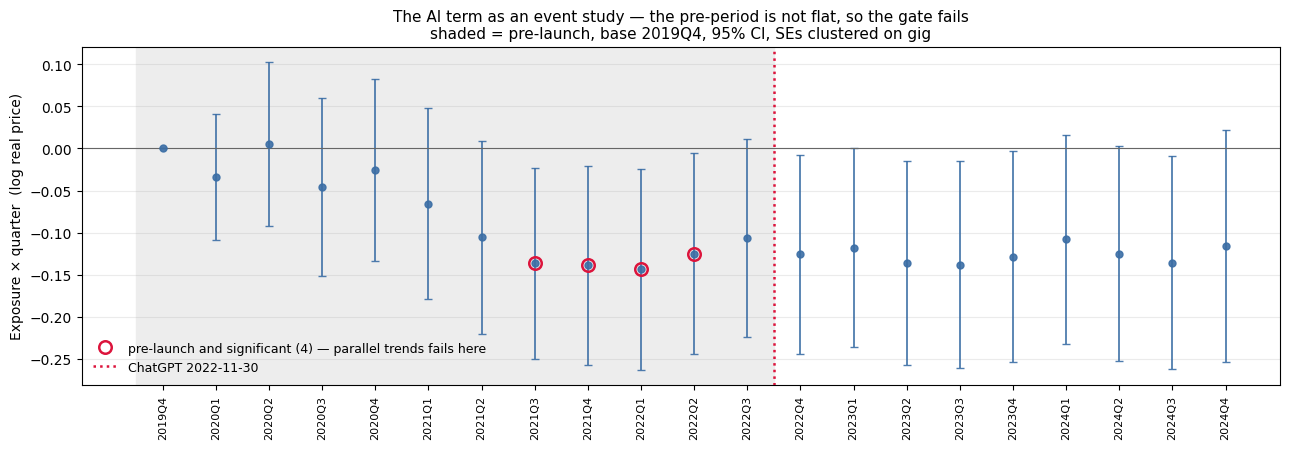

In [ ]:
# Exposure interacted with EVERY quarter — gate A drawn out over the whole window.
# Base is the panel's first quarter, the same base the gate above uses, so the ringed
# points are the ones the gate counts. Under parallel trends the pre-launch
# coefficients are flat at zero; the gate is whether they are.
ES_BASE = QS_PM[0]
ex_all  = [(q, e_vec * (d.quarter == q).to_numpy(float)) for q in QS_PM if q != ES_BASE]
yE, XE, nE, gE = pm.design(d, None, extra=ex_all)
tabE, _ = pm.fe_ols(yE, XE, gE, nE)

es = (tabE[tabE.term.isin([q for q, _ in ex_all])]
        .assign(qi=lambda t: t.term.map(pm.q_to_int))
        .sort_values("qi"))
es = pd.concat([es, pd.DataFrame([{"term": ES_BASE, "coef": 0.0, "se": 0.0, "t": np.nan,
                                   "qi": pm.q_to_int(ES_BASE)}])]).sort_values("qi")

fig, ax = plt.subplots(figsize=(13, 4.6))
xs = np.arange(len(es))
post = es.qi.to_numpy() >= CUT
ax.axvspan(-.5, float(xs[post][0]) - .5, color="0.93", zorder=0)
ax.errorbar(xs, es.coef, yerr=1.96*es.se, fmt="o", ms=5, lw=1.3, capsize=3,
            color="#3b6ea5", ecolor="#3b6ea5", alpha=.9)
bad = (~post) & (es.se.to_numpy() > 0) & (np.abs(es.coef / es.se.replace(0, np.nan)) > 1.96)
ax.plot(xs[bad], es.coef[bad], "o", ms=9, mfc="none", mec="crimson", mew=1.8,
        label=f"pre-launch and significant ({bad.sum()}) — parallel trends fails here")
ax.axhline(0, color="0.4", lw=.8)
ax.axvline(float(xs[post][0]) - .5, color="crimson", ls=":", lw=1.8,
           label="ChatGPT 2022-11-30")
ax.set_xticks(xs); ax.set_xticklabels(es.term, rotation=90, fontsize=8)
ax.set_ylabel("Exposure × quarter  (log real price)")
ax.set_title("The AI term as an event study — the pre-period is not flat, so the gate fails\n"
             f"shaded = pre-launch, base {ES_BASE}, 95% CI, SEs clustered on gig", fontsize=11)
ax.legend(fontsize=9, frameon=False, loc="lower left")
ax.grid(axis="y", alpha=.25)
fig.tight_layout(); plt.show()

### 10.5 Secondary and exploratory — step 75's market-measured exposure

Step 75 measures AI diffusion *inside the market*, from the gig slug in `urlkey`, over
**1,772,000 distinct gigs** — no crawl, and no dependence on step 04's classifier, so
the classifier leak cannot bias it. Entry-cohort AI share runs 0.00–0.16% for eighteen
quarters and then goes **0.16% → 4.97% in one quarter, 2023Q1**.

It is a better regressor than the pre-registered one in every technical respect: it is
in-market rather than crosswalked from occupations, and it varies by category **and**
quarter, so it enters directly and is identified against both fixed effects with no
`Post` interaction. It also ranks the categories the other way round — coding most
AI-branded, translation least, against a prereg that locks translation HIGH and
quarantines coding.

The cell below is the reason this section exists. The coefficient comes back large and
tightly estimated — the kind of number that gets quoted — and then does not survive one
linear trend per category. **A category-by-quarter regressor absorbs any
category-specific time path, AI-driven or not.** This one was measuring "coding rose
and translation did not".

In [ ]:
# NOT pre-registered, and it cannot be promoted after the fact: step 75 ranks the
# categories nearly OPPOSITE to the prereg (translation least AI-branded, coding most).
# It varies by category AND quarter, so it enters directly — identified against both
# fixed effects with no Post interaction.
slug = pm.load_slug_exposure()
ds   = d.merge(slug, on=["category", "quarter"], how="inner")
ai   = ds.ai_share.to_numpy(float)

y6, X6, n6, g6 = pm.design(ds, None, extra=[("AI share", ai)])
tab6, _ = pm.fe_ols(y6, X6, g6, n6)
c6 = float(tab6.loc[tab6.term == "AI share", "coef"].iloc[0])
s6 = float(tab6.loc[tab6.term == "AI share", "se"].iloc[0])
t6 = float(tab6.loc[tab6.term == "AI share", "t"].iloc[0])

# THE TEST THAT DECIDES IT. A category-by-quarter regressor absorbs ANY
# category-specific time path, AI-driven or not. One linear trend per category.
cats_s   = sorted(ds.category.unique())[1:]                # one absorbed
trend_s  = (ds.qi - ds.qi.min()).to_numpy(float)
extra_tr = [(f"trend x {c}", trend_s * (ds.category == c).to_numpy(float)) for c in cats_s]
y7, X7, n7, g7 = pm.design(ds, None, extra=[("AI share", ai)] + extra_tr)
tab7, _ = pm.fe_ols(y7, X7, g7, n7)
c7 = float(tab7.loc[tab7.term == "AI share", "coef"].iloc[0])
s7 = float(tab7.loc[tab7.term == "AI share", "se"].iloc[0])
t7 = float(tab7.loc[tab7.term == "AI share", "t"].iloc[0])

print(f"sample {len(ds):,} obs / {ds.gig_id.nunique():,} gigs")
print(f"AI share, as fitted      {c6:+.4f} (t {t6:+.2f})  ->  "
      f"{100*np.expm1(c6*.10):+.2f}% real price per 10pp of AI-branded share")
print(f"  + one trend per category {c7:+.4f} (t {t7:+.2f})  ->  "
      f"{100*np.expm1(c7*.10):+.2f}% per 10pp")
print(f"\n{'PASS' if (c6*c7>0 and abs(c7)>.5*abs(c6) and abs(t7)>1.96) else 'FAIL'}"
      f" — most of it was a category-specific trend, not AI.")

sample 169,337 obs / 15,676 gigs
AI share, as fitted      +1.2888 (t +11.23)  ->  +13.76% real price per 10pp of AI-branded share
  + one trend per category +0.0727 (t +0.84)  ->  +0.73% per 10pp

FAIL — most of it was a category-specific trend, not AI.


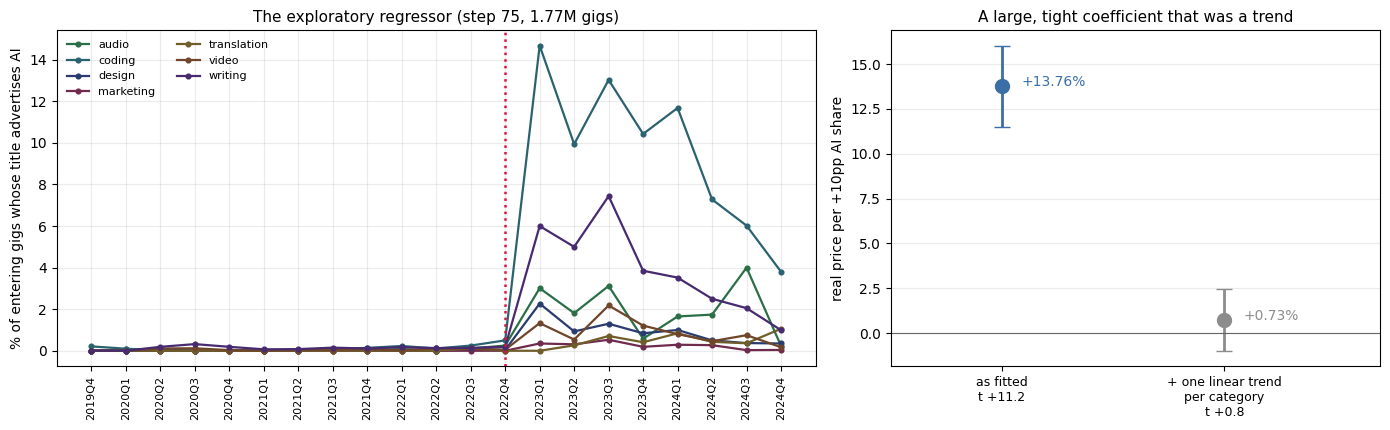

In [ ]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4.4),
                               gridspec_kw={"width_ratios": [1.55, 1]})

# left: what the regressor actually is -- step 75's measure, over 1.77M gigs
for c in FAMS:
    sub = slug[slug.category == c].sort_values("quarter")
    sub = sub[(sub.quarter >= PM_START) & (sub.quarter <= PM_END)]
    axA.plot(sub.quarter, 100*sub.ai_share, lw=1.6, marker="o", ms=3.4,
             color=LBL[c][2], label=c)
axA.axvline(pm.CHATGPT_LAUNCH, color="crimson", ls=":", lw=1.8)
axA.set_ylabel("% of entering gigs whose title advertises AI")
axA.set_title("The exploratory regressor (step 75, 1.77M gigs)", fontsize=11)
axA.tick_params(axis="x", rotation=90, labelsize=8)
axA.legend(fontsize=8, frameon=False, ncol=2); axA.grid(alpha=.25)

# right: and why it does not survive
vals = [(f"as fitted\nt {t6:+.1f}", c6, s6, "#3b6ea5"),
        (f"+ one linear trend\nper category\nt {t7:+.1f}", c7, s7, "0.55")]
for i, (lab, c, s, col) in enumerate(vals):
    axB.errorbar(i, 100*np.expm1(c*.10), yerr=100*np.expm1(1.96*s*.10),
                 fmt="o", ms=10, capsize=6, lw=2, color=col)
    axB.annotate(f"{100*np.expm1(c*.10):+.2f}%", (i, 100*np.expm1(c*.10)),
                 textcoords="offset points", xytext=(14, 0), fontsize=10, color=col)
axB.set_xticks([0, 1]); axB.set_xticklabels([v[0] for v in vals], fontsize=9)
axB.set_xlim(-.5, 1.7); axB.axhline(0, color="0.4", lw=.8)
axB.set_ylabel("real price per +10pp AI share")
axB.set_title("A large, tight coefficient that was a trend", fontsize=11)
axB.grid(axis="y", alpha=.25)
fig.tight_layout(); plt.show()

### Reading §10

**What is estimated cleanly, and belongs in the paper.**

- **Reputation.** A doubling of cumulative reviews carries **+7.33%** in real price
  (t ≈ 26), net of inflation, task value and the common quarter path. Steps 22 and 27
  measured **+7.7%** on different panels in nominal terms; this is an independent
  replication of the treadmill on the balanced panel, in 2020Q1 dollars. Rating adds
  **+10.4% per point**, which is a much weaker estimate (t ≈ 2.8) and should be quoted
  as such.
- **Task value.** SD **1.249 log points** across 15,676 gigs — roughly seven times the
  spread of everything time-varying in the model put together. That is the argument for
  the fixed effect: any proxy for task value would be mis-measuring the largest term.
- **Deflation** removes **−10.2%** of the mean log price over the window. Any nominal
  statement about this panel is a tenth of a log point wrong before anything else is.

**The AI term is a silence, not a zero — and it fails its gate anyway.**

`Exposure × Post` = **−0.0333** (se 0.0246, t −1.35), or **−1.95%** across the
audio-to-translation exposure spread. The MDE at 80% power is **0.0689**, and the point
estimate sits *below* it: this design could not have detected an effect of the size it
estimated, so the null rules nothing out. Report it as a silence.

That is the generous reading. The strict one is that the estimate is not interpretable
at all, because **gate A fails**: 4 of the 11 pre-launch interactions are significant,
and the event-study chart shows why — the exposure gap opens up over 2021, entirely
before ChatGPT exists, and is then **flat across the whole post-period**. The
divergence this design would have attributed to AI had already happened. The trend race
(sign flip) and first differences (t +0.59) say the same thing two more ways. Per the
pre-registration the DiD is dead here and synthetic control is the only fallback left.

One deviation is recorded rather than taken silently: the prereg's placebo break of
**2019Q2 sits before this panel opens**, which makes `Post` all-ones and the
interaction collinear with the gig effects — the first run of step 76 printed a NaN
*t*-statistic and a false PASS. The break is moved to the pre-period midpoint, 2021Q2,
where the test is not vacuous.

**The most useful result in this section is a false positive that was caught.** Step
75's market-measured exposure enters at **+13.76% per 10pp of AI-branded share**, CI
+11.2% to +16.3%, *t* = 11.2 — large, tight, and exactly the shape §10.4's lesson warns
about. One linear trend per category collapses it to **+0.73% (t 0.84)**. It never
measured AI.

> **Standing rule, from this run.** Any category-by-quarter regressor gets
> category-specific trends before its coefficient is quoted anywhere. This is now an
> open item in `plans/todo.md` to apply retroactively across the repo.

**What §10 does not do.** Nothing here is causal. There is no control group beyond
cross-category exposure — every gig met ChatGPT on the same date, the objection §8
already carries — and the parallel-trends gate fails outright. The reputation and
task-value results do not depend on any of that: they are within-gig associations on a
deflated panel, and they are what this section actually establishes.